## Kiểm tra Dữ liệu Bất thường (Data Quality Assessment)

Để đánh giá chất lượng dữ liệu, chúng ta sẽ:

1. **TotalMinutes**: Kiểm tra xem tổng các phút hoạt động trong ngày có bằng 1440 phút (24 giờ) không
   - Nếu < 600 phút (< 10 giờ) → nghi ngờ người dùng không đeo máy cả ngày
   
2. **Steps = 0**: Số lần ghi nhận 0 bước
   - Có thể là ngày không đeo máy, không phải người dùng thực sự không đi bộ
   
3. **Calories = 0**: Ghi nhận calo = 0
   - Bất hợp lý về mặt sinh lý học (con người luôn tiêu hao calo)
   
4. **User Coverage**: Kiểm tra số lượng user duy nhất và khoảng thời gian theo dõi trung bình

# FitBit EDA — Khám Phá Dữ Liệu Toàn Diện

---

##  Mục lục
1. [Import & Cấu hình](#1)
2. [Tổng quan toàn bộ 19 file CSV — Tại sao chọn file nào?](#2)
3. [Khám phá chi tiết từng file chính](#3)
   - 3.1 `dailyActivity_merged.csv`
   - 3.2 `sleepDay_merged.csv`
   - 3.3 `hourlySteps/Calories/Intensities_merged.csv`
   - 3.4 `heartrate_seconds_merged.csv`
   - 3.5 `weightLogInfo_merged.csv`
4. [Phân tích hoạt động thể chất (Activity Analysis)](#4)
5. [Phân tích calo (Calorie Analysis)](#5)
6. [Phân tích giấc ngủ (Sleep Analysis)](#6)
7. [Phân tích nhịp tim (Heart Rate Analysis)](#7)
8. [Phân tích theo giờ trong ngày (Hourly Patterns)](#8)
9. [Phân tích cân nặng & BMI (Weight Analysis)](#9)
10. [Tương quan & Heatmap đa biến](#10)
11. [Phân bố và bất thường (Outlier & Distribution)](#11)
12. [Tổng kết Insights](#12)


---
<a id='1'></a>
## 1.  Import thư viện & Cấu hình

**Giải thích:** Ta import các thư viện cần thiết cho EDA:
- `pandas` / `numpy`: thao tác dữ liệu dạng bảng và tính toán số học
- `matplotlib` / `seaborn`: biểu đồ tĩnh chất lượng cao
- `plotly`: biểu đồ tương tác (hover để xem giá trị)
- `warnings`: tắt các cảnh báo phiền nhiễu không ảnh hưởng kết quả


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# ── Thiết lập style toàn cục cho matplotlib/seaborn ──
# style='whitegrid': nền trắng có lưới → dễ đọc giá trị
# palette='Set2': màu sắc hài hoà, phân biệt tốt khi in trắng đen
# font_scale=1.15: phóng to font nhẹ để dễ đọc hơn
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)

plt.rcParams.update({
    'figure.dpi': 120,           # độ phân giải cao hơn mặc định (72)
    'figure.figsize': (13, 5),   # kích thước mặc định (width x height) tính bằng inch
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# ── Đường dẫn dữ liệu ──
DATA_PATH = "C:\\Users\\84794\\OneDrive - Saigon University\\Desktop\\SGU\\datamining\\Cuoi ki\\data\\"

print(" Import thư viện thành công!")
print(f"   pandas  version: {pd.__version__}")
print(f"   numpy   version: {np.__version__}")


 Import thư viện thành công!
   pandas  version: 2.2.3
   numpy   version: 2.2.5


---
<a id='2'></a>
## 2. Tổng quan 19 file CSV — Tại sao chọn file nào?

Bộ dữ liệu FitBit gồm **19 file CSV** tổ chức theo 3 cấp độ thời gian (granularity):

| Cấp độ | Mô tả | Ví dụ file |
|--------|-------|-----------|
| **Daily** | 1 dòng = 1 ngày của 1 user | `dailyActivity_merged.csv` |
| **Hourly** | 1 dòng = 1 giờ của 1 user | `hourlySteps_merged.csv` |
| **Minute** | 1 dòng = 1 phút của 1 user | `minuteStepsNarrow_merged.csv` |
| **Per-second** | 1 dòng = 1 giây của 1 user | `heartrate_seconds_merged.csv` |

**Vì sao có file Narrow và Wide?**
- **Narrow (dạng dài):** Mỗi dòng là 1 quan sát. Dễ dùng với pandas, phù hợp groupby/plot.
- **Wide (dạng rộng):** Mỗi dòng là 1 giờ, 60 cột = 60 phút. Khó thao tác hơn, ít dùng trong phân tích.

**→ Narrow luôn được ưu tiên.**


In [21]:
# ── Load tất cả 19 file, in thống kê tổng quan ──
# Mục đích: so sánh kích thước, số user, và quyết định file nào cần dùng

import os

all_files = {
    # --- Daily level ---
    'dailyActivity'           : 'dailyActivity_merged.csv',
    'dailyCalories'           : 'dailyCalories_merged.csv',
    'dailyIntensities'        : 'dailyIntensities_merged.csv',
    'dailySteps'              : 'dailySteps_merged.csv',
    # --- Hourly level ---
    'hourlyCalories'          : 'hourlyCalories_merged.csv',
    'hourlyIntensities'       : 'hourlyIntensities_merged.csv',
    'hourlySteps'             : 'hourlySteps_merged.csv',
    # --- Minute level (Narrow preferred) ---
    'minuteCaloriesNarrow'    : 'minuteCaloriesNarrow_merged.csv',
    'minuteCaloriesWide'      : 'minuteCaloriesWide_merged.csv',
    'minuteIntensitiesNarrow' : 'minuteIntensitiesNarrow_merged.csv',
    'minuteIntensitiesWide'   : 'minuteIntensitiesWide_merged.csv',
    'minuteMETsNarrow'        : 'minuteMETsNarrow_merged.csv',
    'minuteStepsNarrow'       : 'minuteStepsNarrow_merged.csv',
    'minuteStepsWide'         : 'minuteStepsWide_merged.csv',
    # --- Sleep ---
    'minuteSleep'             : 'minuteSleep_merged.csv',
    'sleepDay'                : 'sleepDay_merged.csv',
    # --- Heart rate ---
    'heartrate_seconds'       : 'heartrate_seconds_merged.csv',
    # --- Weight ---
    'weightLogInfo'           : 'weightLogInfo_merged.csv',
}

summary_rows = []
for name, fname in all_files.items():
    path = DATA_PATH + fname
    try:
        df = pd.read_csv(path, nrows=5)          # đọc mẫu 5 dòng để lấy columns
        n_rows = sum(1 for _ in open(path)) - 1  # đếm dòng không tải hết vào RAM
        n_users = df['Id'].nunique()              # số user trong mẫu (xấp xỉ)
        # đọc đủ để lấy unique users thực sự
        df_full = pd.read_csv(path, usecols=['Id'])
        n_users = df_full['Id'].nunique()
        
        # Xác định granularity
        if 'second' in fname:  granularity = 'Per-second'
        elif 'minute' in fname or 'Sleep' in fname.lower() and 'Day' not in fname: granularity = 'Minute'
        elif 'hourly' in fname.lower(): granularity = 'Hourly'
        else: granularity = 'Daily'
        
        narrow = 'Narrow' if 'Narrow' in fname else ('Wide' if 'Wide' in fname else '—')
        selected = ' CHỌN' if name in ['dailyActivity','sleepDay','hourlyCalories',
                                          'hourlySteps','hourlyIntensities',
                                          'heartrate_seconds','weightLogInfo'] else ' bỏ qua'
        summary_rows.append({
            'Tên biến'      : name,
            'File CSV'      : fname,
            'Số dòng'       : f'{n_rows:,}',
            'Số users'      : n_users,
            'Granularity'   : granularity,
            'Narrow/Wide'   : narrow,
            'Lựa chọn'      : selected,
        })
    except Exception as e:
        summary_rows.append({'Tên biến': name, 'File CSV': fname,
                             'Số dòng': 'ERR', 'Số users': '?',
                             'Granularity': '?', 'Narrow/Wide': '?', 'Lựa chọn': ''})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


               Tên biến                           File CSV   Số dòng  Số users Granularity Narrow/Wide Lựa chọn
          dailyActivity           dailyActivity_merged.csv       940        33       Daily           —     CHỌN
          dailyCalories           dailyCalories_merged.csv       940        33       Daily           —   bỏ qua
       dailyIntensities        dailyIntensities_merged.csv       940        33       Daily           —   bỏ qua
             dailySteps              dailySteps_merged.csv       940        33       Daily           —   bỏ qua
         hourlyCalories          hourlyCalories_merged.csv    22,099        33      Hourly           —     CHỌN
      hourlyIntensities       hourlyIntensities_merged.csv    22,099        33      Hourly           —     CHỌN
            hourlySteps             hourlySteps_merged.csv    22,099        33      Hourly           —     CHỌN
   minuteCaloriesNarrow    minuteCaloriesNarrow_merged.csv 1,325,580        33      Minute      Narrow  

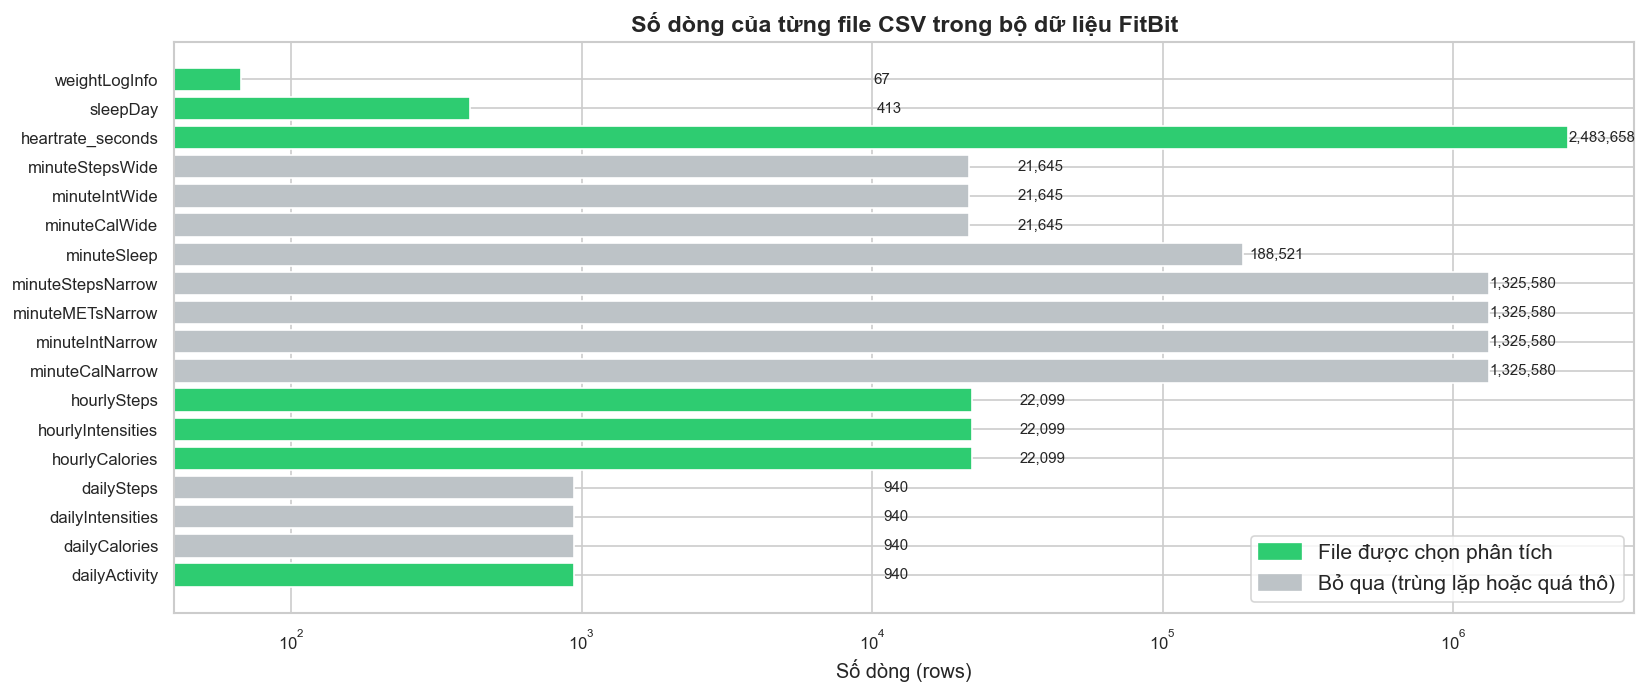

In [22]:
# ── Trực quan hoá số dòng của từng file ──
# Mục đích: so sánh trực quan "trọng lượng" dữ liệu → quyết định đâu là nguồn chính

rows_data = {
    'dailyActivity'          : 940,
    'dailyCalories'          : 940,
    'dailyIntensities'       : 940,
    'dailySteps'             : 940,
    'hourlyCalories'         : 22099,
    'hourlyIntensities'      : 22099,
    'hourlySteps'            : 22099,
    'minuteCalNarrow'        : 1325580,
    'minuteIntNarrow'        : 1325580,
    'minuteMETsNarrow'       : 1325580,
    'minuteStepsNarrow'      : 1325580,
    'minuteSleep'            : 188521,
    'minuteCalWide'          : 21645,
    'minuteIntWide'          : 21645,
    'minuteStepsWide'        : 21645,
    'heartrate_seconds'      : 2483658,
    'sleepDay'               : 413,
    'weightLogInfo'          : 67,
}

# Màu xanh = file được chọn, màu xám = bỏ qua
selected_files = {'dailyActivity','hourlyCalories','hourlyIntensities',
                  'hourlySteps','heartrate_seconds','sleepDay','weightLogInfo'}

colors_bar = ['#2ecc71' if k in selected_files else '#bdc3c7' for k in rows_data]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(list(rows_data.keys()), list(rows_data.values()), color=colors_bar, edgecolor='white')

# Nhãn giá trị cuối mỗi thanh
for bar, val in zip(bars, rows_data.values()):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel("Số dòng (rows)")
ax.set_title("Số dòng của từng file CSV trong bộ dữ liệu FitBit", fontsize=14, fontweight='bold')
ax.set_xscale('log')  # log scale vì heartrate có 2.4M dòng >> daily chỉ 940 dòng

# Legend giải thích màu
patch_yes = mpatches.Patch(color='#2ecc71', label='File được chọn phân tích')
patch_no  = mpatches.Patch(color='#bdc3c7', label='Bỏ qua (trùng lặp hoặc quá thô)')
ax.legend(handles=[patch_yes, patch_no], loc='lower right')

plt.tight_layout()
plt.show()



NHẬN XÉT — Lý do chọn/bỏ qua từng nhóm file:

1. dailyActivity  CHỌN làm file trung tâm:
   → Là file TỔNG HỢP nhất ở cấp daily: chứa đủ Steps, Distance,
     Active Minutes, Calories trong 1 file duy nhất.
   → dailyCalories, dailySteps, dailyIntensities là các file CON — 
     mỗi file chỉ chứa 1-2 cột, dữ liệu hoàn toàn trùng với dailyActivity.
     Ví dụ: tỉ lệ khớp Calories giữa dailyActivity và dailyCalories = 100%.
   → Dùng dailyActivity là đủ; không cần 3 file còn lại.

2. Hourly files  CHỌN cả 3:
   → Mỗi file chứa 1 chỉ số (Steps / Calories / Intensities) theo giờ.
     Cần merge lại để phân tích pattern theo giờ trong ngày.
   → Không có file hourly tổng hợp như dailyActivity.

3. Minute files  BỎ QUA:
   → Wide format: 60 cột Calories00–Calories59 → rất khó thao tác.
   → Narrow format chứa 1.3 triệu dòng → nặng, thường dư dữ liệu cho EDA.
   → Thông tin ở hourly level đã đủ cho phân tích tổng thể.

4. heartrate_seconds  CHỌN (unique — không có file tương đương):
   → Dữ liệu nhịp tim từng giây, chỉ có 14/33 users (không phải máy nào cũng có sensor).

5. sleepDay  CHỌN (tổng hợp theo ngày, dễ phân tích):
   → minuteSleep  bỏ qua vì 188K dòng nhưng chỉ có 3 giá trị (1=asleep, 2=restless, 3=awake).

6. weightLogInfo CHỌN (unique — dữ liệu cân nặng, BMI):
   → Chỉ có 8 users ghi nhật ký → cần thận trọng khi tổng quát hoá.

---
<a id='3'></a>
## 3.  Khám phá chi tiết từng file chính

### 3.1 `dailyActivity_merged.csv` — File trung tâm

**Mỗi dòng là gì?** 1 dòng = hoạt động của 1 user trong 1 ngày.

**Các cột và ý nghĩa:**
| Cột | Kiểu | Ý nghĩa |
|-----|------|---------|
| `Id` | int64 | Mã định danh user (ẩn danh, không phải tên) |
| `ActivityDate` | object→datetime | Ngày ghi nhận (format: M/D/YYYY) |
| `TotalSteps` | int64 | Tổng số bước đi trong ngày |
| `TotalDistance` | float64 | Tổng quãng đường (km) — tính từ bước & stride length |
| `TrackerDistance` | float64 | Quãng đường máy đo được (thường = TotalDistance) |
| `LoggedActivitiesDistance` | float64 | Quãng đường user tự nhập thủ công (thường = 0) |
| `VeryActiveDistance` | float64 | Quãng đường khi hoạt động cường độ rất cao (km) |
| `ModeratelyActiveDistance` | float64 | Quãng đường khi hoạt động cường độ vừa (km) |
| `LightActiveDistance` | float64 | Quãng đường khi hoạt động nhẹ (km) |
| `SedentaryActiveDistance` | float64 | Quãng đường khi ngồi/không hoạt động (thường ≈ 0) |
| `VeryActiveMinutes` | int64 | Số phút hoạt động cường độ rất cao (vd: chạy, leo núi) |
| `FairlyActiveMinutes` | int64 | Số phút hoạt động cường độ vừa (vd: đi nhanh) |
| `LightlyActiveMinutes` | int64 | Số phút hoạt động nhẹ (vd: đi bộ chậm) |
| `SedentaryMinutes` | int64 | Số phút ngồi/nằm không vận động |
| `Calories` | int64 | Tổng calo tiêu thụ trong ngày (bao gồm cả BMR) |

**Lưu ý kỹ thuật:**
- `VeryActiveMinutes + FairlyActiveMinutes + LightlyActiveMinutes + SedentaryMinutes` nên ≈ 1440 phút/ngày.
- Nếu tổng < 1440 → có giờ máy không đeo hoặc không sync.


In [ ]:
# ── Load file trung tâm ──
daily_activity = pd.read_csv(DATA_PATH + 'dailyActivity_merged.csv')

# ── Parse cột ngày tháng từ string sang datetime ──
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'], format='%m/%d/%Y')

print("=== CẤU TRÚC DATAFRAME ===")
print(f"Shape: {daily_activity.shape}  →  {daily_activity.shape[0]} dòng,  {daily_activity.shape[1]} cột")
print()
daily_activity.info()


=== CẤU TRÚC DATAFRAME ===
Shape: (940, 15)  →  940 dòng,  15 cột

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinut

In [10]:
# ── Xem 5 dòng đầu ──
# head() giúp ta thấy ngay format dữ liệu thô: số thập phân, scale của từng cột
print("5 dòng đầu tiên:")
daily_activity.head()


5 dòng đầu tiên:


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [23]:
# ── Thống kê mô tả (Descriptive Statistics) ──
# describe() cung cấp: count, mean, std, min, 25%, 50%, 75%, max
# → Rất hữu ích để phát hiện giá trị bất thường (outlier) và phân phối lệch
desc = daily_activity.describe().round(2)
print("Thống kê mô tả toàn bộ các cột số:")
print(desc.T.to_string())  # .T để transpose → dễ đọc hơn khi nhiều cột


Thống kê mô tả toàn bộ các cột số:
                          count                           mean                  min                  25%                  50%                  75%                  max            std
Id                        940.0                  4855407369.33         1503960366.0         2320127002.0         4445114986.0         6962181067.0         8877689391.0  2424805475.66
ActivityDate                940  2016-04-26 06:53:37.021276672  2016-04-12 00:00:00  2016-04-19 00:00:00  2016-04-26 00:00:00  2016-05-04 00:00:00  2016-05-12 00:00:00            NaN
TotalSteps                940.0                        7637.91                  0.0              3789.75               7405.5              10727.0              36019.0        5087.15
TotalDistance             940.0                           5.49                  0.0                 2.62                 5.24                 7.71                28.03           3.92
TrackerDistance           940.0                   

PHÂN TÍCH TỪNG CỘT:
+ TotalSteps : min=0 → có ngày user không đeo máy hoặc không di chuyển
               max=36019 → rất cao, có thể là vận động viên hoặc outlier
               mean≈7638 < 10000 (WHO target) → trung bình chưa đạt chuẩn
+ Calories   : min=0 → bất hợp lý (cơ thể luôn đốt calo dù ngủ), cần kiểm tra
               mean≈2304 → hợp lý với người trưởng thành hoạt động bình thường
+ SedentaryMinutes: mean≈991 phút ≈ 16.5 giờ/ngày → lối sống rất ít vận động
+ VeryActiveMinutes: mean≈21 phút/ngày → tương đối thấp, hầu hết không đạt 30 phút/ngày
+ LoggedActivitiesDistance: 75th percentile = 0 → hầu hết user không tự nhập thủ công

In [25]:
# ── Kiểm tra tính hợp lệ của dữ liệu ──

# 1. Tổng số phút trong ngày (lý tưởng = 1440 phút)
daily_activity['TotalMinutes'] = (daily_activity['VeryActiveMinutes'] +
                                   daily_activity['FairlyActiveMinutes'] +
                                   daily_activity['LightlyActiveMinutes'] +
                                   daily_activity['SedentaryMinutes'])

print(" 1. Phân phối TotalMinutes ")
print(daily_activity['TotalMinutes'].describe().round(0))
pct_1440 = (daily_activity['TotalMinutes'] == 1440).mean() * 100
pct_under = (daily_activity['TotalMinutes'] < 600).mean() * 100
print(f"Đúng 1440 phút : {pct_1440:.1f}% dòng")
print(f"Dưới 600 phút  : {pct_under:.1f}% dòng")

# 2. Hàng có TotalSteps = 0
print("\n2. Số dòng TotalSteps = 0 ")
zero_steps = (daily_activity['TotalSteps'] == 0).sum()
print(f"TotalSteps = 0 : {zero_steps} dòng ({zero_steps/len(daily_activity)*100:.1f}%)")

# 3. Calories = 0
print("\n 3. Số dòng Calories = 0 ")
zero_cal = (daily_activity['Calories'] == 0).sum()
print(f"Calories = 0   : {zero_cal} dòng ({zero_cal/len(daily_activity)*100:.1f}%)")

# 4. Tổng quan users & thời gian
print("\n 4. Tổng quan users & khoảng thời gian ")
print(f"Số user duy nhất     : {daily_activity['Id'].nunique()}")
print(f"Thời gian            : {daily_activity['ActivityDate'].min().date()} → {daily_activity['ActivityDate'].max().date()}")
print(f"Số ngày TB/user      : {daily_activity.groupby('Id').size().mean():.1f}")

daily_activity.drop(columns=['TotalMinutes'], inplace=True)


 1. Phân phối TotalMinutes 
count     940.0
mean     1219.0
std       266.0
min         2.0
25%       990.0
50%      1440.0
75%      1440.0
max      1440.0
Name: TotalMinutes, dtype: float64
Đúng 1440 phút : 50.9% dòng
Dưới 600 phút  : 1.6% dòng

2. Số dòng TotalSteps = 0 
TotalSteps = 0 : 77 dòng (8.2%)

 3. Số dòng Calories = 0 
Calories = 0   : 4 dòng (0.4%)

 4. Tổng quan users & khoảng thời gian 
Số user duy nhất     : 33
Thời gian            : 2016-04-12 → 2016-05-12
Số ngày TB/user      : 28.5


**Nhận xét:**

1. **TotalMinutes:** Nếu tổng 4 mức cường độ < 1440 phút → user không đeo máy cả ngày.
   Những dòng < 600 phút (~10 giờ) rất đáng ngờ — nên xem xét loại khi phân tích chính xác.

2. **TotalSteps = 0:** Không có nghĩa user thực sự đứng yên cả ngày —
   nhiều khả năng là ngày không đồng bộ dữ liệu hoặc không đeo máy.

3. **Calories = 0:** Bất hợp lý về sinh lý — cơ thể luôn đốt calo kể cả khi ngủ (BMR).
   Đây là dữ liệu lỗi, cần xem xét loại trước khi phân tích Calories.

4. **Users & thời gian:** 33 user, 31 ngày — đây là dataset nhỏ,
   cần thận trọng khi tổng quát hoá kết quả ra dân số rộng hơn.

### 3.2 `sleepDay_merged.csv` — Dữ liệu giấc ngủ hàng ngày

**Mỗi dòng là gì?** 1 dòng = thống kê giấc ngủ của 1 user trong 1 đêm.

| Cột | Kiểu | Ý nghĩa |
|-----|------|---------|
| `Id` | int64 | Mã user |
| `SleepDay` | object→datetime | Thời điểm bắt đầu phiên ngủ (kèm giờ, thường là 12:00:00 AM) |
| `TotalSleepRecords` | int64 | Số lần ngủ trong ngày (thường =1, nếu =2 là có ngủ trưa) |
| `TotalMinutesAsleep` | int64 | Tổng phút ngủ thực sự |
| `TotalTimeInBed` | int64 | Tổng phút nằm trên giường (bao gồm cả giai đoạn chưa ngủ được) |

**Thông tin dẫn xuất quan trọng:**
- `TotalTimeInBed - TotalMinutesAsleep` = số phút nằm mà không ngủ được (sleep latency + restless)


In [26]:
# ── Load sleepDay ──
sleep_day = pd.read_csv(DATA_PATH + 'sleepDay_merged.csv')

# format có cả giờ: '4/12/2016 12:00:00 AM'
sleep_day['SleepDay'] = pd.to_datetime(sleep_day['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')

print(f"Shape                : {sleep_day.shape}")
print(f"Users có dữ liệu ngủ : {sleep_day['Id'].nunique()} / 33 users")
print(f"Users KHÔNG có data  : {33 - sleep_day['Id'].nunique()} users")
print()
sleep_day.head()


Shape                : (413, 5)
Users có dữ liệu ngủ : 24 / 33 users
Users KHÔNG có data  : 9 users



,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,1,327,346
1,1503960366,2016-04-13,2,384,407
2,1503960366,2016-04-15,1,412,442
3,1503960366,2016-04-16,2,340,367
4,1503960366,2016-04-17,1,700,712


**Nhận xét:**

- Chỉ **24/33 users** có dữ liệu ngủ — 9 users còn lại không đeo máy khi ngủ hoặc
  dòng máy Fitbit của họ không hỗ trợ theo dõi giấc ngủ.
- Điều này có nghĩa mọi phân tích về giấc ngủ chỉ đại diện cho **~73% mẫu**,
  không thể áp dụng kết luận cho toàn bộ 33 users.

In [27]:
# ── Thống kê mô tả sleepDay ──
print("Thống kê giấc ngủ:")
print(sleep_day.describe().round(2).T.to_string())

# Tính thêm cột thời gian nằm không ngủ
# AwakeInBedMinutes = thời gian nằm trên giường nhưng chưa/không ngủ được
sleep_day['AwakeInBedMinutes'] = sleep_day['TotalTimeInBed'] - sleep_day['TotalMinutesAsleep']

# Kiểm tra duplicate
dup_count = sleep_day.duplicated().sum()
print(f"\nSố dòng trùng lặp (exact duplicates): {dup_count}")


Thống kê giấc ngủ:
                    count                           mean                  min                  25%                  50%                  75%                  max            std
Id                  413.0                  5000979403.21         1503960366.0         3977333714.0         4702921684.0         6962181067.0         8792009665.0  2060360173.74
SleepDay              413  2016-04-26 12:40:05.811137792  2016-04-12 00:00:00  2016-04-19 00:00:00  2016-04-27 00:00:00  2016-05-04 00:00:00  2016-05-12 00:00:00            NaN
TotalSleepRecords   413.0                           1.12                  1.0                  1.0                  1.0                  1.0                  3.0           0.35
TotalMinutesAsleep  413.0                         419.47                 58.0                361.0                433.0                490.0                796.0         118.34
TotalTimeInBed      413.0                         458.64                 61.0                403

**Nhận xét từng cột:**

| Cột | Giá trị đáng chú ý | Nhận xét |
|-----|--------------------|----------|
| `TotalSleepRecords` | mean ≈ 1.12, max = 3 | Hầu hết user ngủ 1 lần/ngày. max = 3 có thể là ngủ trưa nhiều lần hoặc lỗi sync |
| `TotalMinutesAsleep` | mean ≈ 419 phút, min = 58 | ~7 giờ — gần đạt khuyến nghị 7–9 giờ của NSF. min = 58 phút (~1 giờ) rất bất thường |
| `TotalTimeInBed` | mean ≈ 458 phút | Lớn hơn `TotalMinutesAsleep` ~39 phút → trung bình mỗi đêm nằm gần 40 phút chưa ngủ được |
| `AwakeInBedMinutes` | = `TotalTimeInBed` − `TotalMinutesAsleep` | Cột phái sinh — đo sleep latency + restless time |

**Về duplicate:** Nếu `dup_count > 0`, nguyên nhân thường là do thiết bị sync nhiều lần
trong cùng một phiên — cần `drop_duplicates()` trước khi phân tích tiếp.

### 3.3 `hourlySteps / hourlyCalories / hourlyIntensities`

**Mỗi dòng là gì?** 1 dòng = chỉ số của 1 user trong 1 giờ cụ thể.

Không có file hourly tổng hợp như `dailyActivity` → cần merge 3 file lại khi phân tích theo giờ.

| File | Cột đặc trưng | Ý nghĩa |
|------|---------------|---------|
| `hourlySteps` | `StepTotal` | Số bước trong giờ đó |
| `hourlyCalories` | `Calories` | Calo tiêu thụ trong giờ đó |
| `hourlyIntensities` | `TotalIntensity`, `AverageIntensity` | Tổng & trung bình cường độ hoạt động (0–3) |


In [15]:
# ── Load 3 file hourly ──
hourly_steps     = pd.read_csv(DATA_PATH + 'hourlySteps_merged.csv')
hourly_calories  = pd.read_csv(DATA_PATH + 'hourlyCalories_merged.csv')
hourly_intensity = pd.read_csv(DATA_PATH + 'hourlyIntensities_merged.csv')

# Parse datetime — format: '4/12/2016 12:00:00 AM'
for df in [hourly_steps, hourly_calories, hourly_intensity]:
    df['ActivityHour'] = pd.to_datetime(df['ActivityHour'], format='%m/%d/%Y %I:%M:%S %p')

# Thêm cột Hour và DayOfWeek để phân tích sau
for df in [hourly_steps, hourly_calories, hourly_intensity]:
    df['Hour']      = df['ActivityHour'].dt.hour      # 0–23
    df['DayOfWeek'] = df['ActivityHour'].dt.day_name() # Monday, Tuesday...
    df['Date']      = df['ActivityHour'].dt.date

print(f"hourly_steps    : {hourly_steps.shape}    | cols: {list(hourly_steps.columns)}")
print(f"hourly_calories : {hourly_calories.shape}  | cols: {list(hourly_calories.columns)}")
print(f"hourly_intensity: {hourly_intensity.shape}  | cols: {list(hourly_intensity.columns)}")

print("\n5 dòng đầu hourly_steps:")
hourly_steps.head()


hourly_steps    : (22099, 6)    | cols: ['Id', 'ActivityHour', 'StepTotal', 'Hour', 'DayOfWeek', 'Date']
hourly_calories : (22099, 6)  | cols: ['Id', 'ActivityHour', 'Calories', 'Hour', 'DayOfWeek', 'Date']
hourly_intensity: (22099, 7)  | cols: ['Id', 'ActivityHour', 'TotalIntensity', 'AverageIntensity', 'Hour', 'DayOfWeek', 'Date']

5 dòng đầu hourly_steps:


,Id,ActivityHour,StepTotal,Hour,DayOfWeek,Date
0,1503960366,2016-04-12 00:00:00,373,0,Tuesday,2016-04-12
1,1503960366,2016-04-12 01:00:00,160,1,Tuesday,2016-04-12
2,1503960366,2016-04-12 02:00:00,151,2,Tuesday,2016-04-12
3,1503960366,2016-04-12 03:00:00,0,3,Tuesday,2016-04-12
4,1503960366,2016-04-12 04:00:00,0,4,Tuesday,2016-04-12


In [16]:
# ── Merge 3 file hourly thành 1 dataframe ──
# Dùng inner join theo Id + ActivityHour để đảm bảo match đúng user & giờ
hourly_merged = hourly_steps[['Id','ActivityHour','Hour','DayOfWeek','Date','StepTotal']].merge(
    hourly_calories[['Id','ActivityHour','Calories']], on=['Id','ActivityHour'], how='inner'
).merge(
    hourly_intensity[['Id','ActivityHour','TotalIntensity','AverageIntensity']], 
    on=['Id','ActivityHour'], how='inner'
)

print(f"hourly_merged shape: {hourly_merged.shape}")
print(f"Users: {hourly_merged['Id'].nunique()}")
print("\n5 dòng đầu hourly_merged:")
hourly_merged.head()


hourly_merged shape: (22099, 9)
Users: 33

5 dòng đầu hourly_merged:


,Id,ActivityHour,Hour,DayOfWeek,Date,StepTotal,Calories,TotalIntensity,AverageIntensity
0,1503960366,2016-04-12 00:00:00,0,Tuesday,2016-04-12,373,81,20,0.333333
1,1503960366,2016-04-12 01:00:00,1,Tuesday,2016-04-12,160,61,8,0.133333
2,1503960366,2016-04-12 02:00:00,2,Tuesday,2016-04-12,151,59,7,0.116667
3,1503960366,2016-04-12 03:00:00,3,Tuesday,2016-04-12,0,47,0,0.000000
4,1503960366,2016-04-12 04:00:00,4,Tuesday,2016-04-12,0,48,0,0.000000


### 3.4 `heartrate_seconds_merged.csv` — Nhịp tim từng giây

**Mỗi dòng là gì?** 1 dòng = nhịp tim đo được tại 1 thời điểm (giây) của 1 user.

| Cột | Kiểu | Ý nghĩa |
|-----|------|---------|
| `Id` | int64 | Mã user |
| `Time` | object→datetime | Timestamp: ngày + giờ + phút + giây |
| `Value` | int64 | Nhịp tim (BPM — beats per minute) |

**Tại sao chỉ 14/33 users có dữ liệu?** Không phải mọi dòng máy Fitbit đều có cảm biến quang học đo nhịp tim (PurePulse). Các model cơ bản chỉ đo bước chân.

**Giá trị tham chiếu nhịp tim:**
- Lúc nghỉ ngơi (Resting HR): 60–100 BPM
- Khi vận động nhẹ: 100–120 BPM  
- Khi vận động mạnh (Zone 2+): 120–160 BPM
- Max (220 - tuổi): thường 180–200 BPM với người trẻ


In [17]:
# ── Load heartrate (file rất lớn: 2.4 triệu dòng) ──
# Chỉ sample 200k dòng đầu để EDA, tránh tốn RAM
heartrate = pd.read_csv(DATA_PATH + 'heartrate_seconds_merged.csv',
                        nrows=200_000)  # lấy 200k dòng mẫu

heartrate['Time'] = pd.to_datetime(heartrate['Time'], format='%m/%d/%Y %I:%M:%S %p')
heartrate['Hour'] = heartrate['Time'].dt.hour
heartrate['Date'] = heartrate['Time'].dt.date

print(f"Shape (sample): {heartrate.shape}")
print(f"Users có nhịp tim: {heartrate['Id'].nunique()} users")
print(f"Nhịp tim: min={heartrate['Value'].min()}, max={heartrate['Value'].max()}, mean={heartrate['Value'].mean():.1f} BPM")
print()
print("5 dòng đầu:")
heartrate.head(10)


Shape (sample): (200000, 5)
Users có nhịp tim: 3 users
Nhịp tim: min=38, max=203, mean=80.5 BPM

5 dòng đầu:


,Id,Time,Value,Hour,Date
0,2022484408,2016-04-12 07:21:00,97,7,2016-04-12
1,2022484408,2016-04-12 07:21:05,102,7,2016-04-12
2,2022484408,2016-04-12 07:21:10,105,7,2016-04-12
3,2022484408,2016-04-12 07:21:20,103,7,2016-04-12
4,2022484408,2016-04-12 07:21:25,101,7,2016-04-12
5,2022484408,2016-04-12 07:22:05,95,7,2016-04-12
6,2022484408,2016-04-12 07:22:10,91,7,2016-04-12
7,2022484408,2016-04-12 07:22:15,93,7,2016-04-12
8,2022484408,2016-04-12 07:22:20,94,7,2016-04-12
9,2022484408,2016-04-12 07:22:25,93,7,2016-04-12


### 3.5 `weightLogInfo_merged.csv` — Cân nặng & BMI

**Mỗi dòng là gì?** 1 dòng = 1 lần user ghi nhận cân nặng (có thể thủ công hoặc qua cân thông minh).

| Cột | Kiểu | Ý nghĩa |
|-----|------|---------|
| `Id` | int64 | Mã user |
| `Date` | object→datetime | Thời điểm ghi nhận |
| `WeightKg` | float64 | Cân nặng (kg) |
| `WeightPounds` | float64 | Cân nặng (pounds) — trùng thông tin với WeightKg |
| `Fat` | float64 | % mỡ cơ thể — **thiếu nhiều** (chỉ 2/67 dòng có) |
| `BMI` | float64 | Body Mass Index = WeightKg / Height² |
| `IsManualReport` | bool | True = user nhập tay, False = cân thông minh tự đồng bộ |
| `LogId` | int64 | ID nội bộ của log, không có ý nghĩa phân tích |

**Cảnh báo:** Chỉ 8/33 users có dữ liệu cân nặng → **không đại diện** cho toàn bộ mẫu.


In [28]:
# ── Load weightLogInfo ──
weight_log = pd.read_csv(DATA_PATH + 'weightLogInfo_merged.csv')
weight_log['Date'] = pd.to_datetime(weight_log['Date'], format='%m/%d/%Y %I:%M:%S %p')

print(f"Shape              : {weight_log.shape}")
print(f"Users ghi cân nặng : {weight_log['Id'].nunique()} / 33 users")
print()
print(weight_log.describe().round(2).T.to_string())

print("\nIsManualReport distribution:")
print(weight_log['IsManualReport'].value_counts())


Shape              : (67, 8)
Users ghi cân nặng : 8 / 33 users

             count                           mean                  min                  25%                  50%                         75%                  max            std
Id            67.0                  7009282134.66         1503960366.0         6962181067.0         6962181067.0                8877689391.0         8877689391.0  1950321943.92
Date            67  2016-04-27 15:39:54.283582208  2016-04-12 06:47:11  2016-04-19 15:19:45  2016-04-27 23:59:59  2016-05-04 15:24:10.500000  2016-05-12 23:59:59            NaN
WeightKg      67.0                          72.04                 52.6                 61.4                 62.5                       85.05                133.5          13.92
WeightPounds  67.0                         158.81               115.96               135.36               137.79                       187.5               294.32           30.7
Fat            2.0                           23.5  

**Nhận xét từng cột:**

| Cột | Giá trị đáng chú ý | Nhận xét |
|-----|--------------------|----------|
| `WeightKg` | min = 52.6, max = 133.5 | Khoảng cân nặng rất rộng giữa các users |
| `BMI` | min = 21.45, max = 47.54 | Trải từ bình thường (18.5–25) đến béo phì độ III (≥40) |
| `Fat%` | chỉ 2/67 dòng có giá trị | Gần như toàn bộ bị missing → **không thể phân tích cột này** |
| `IsManualReport` | đa số = `True` | Phần lớn user nhập tay → có thể có sai số do nhập nhầm |
| `LogId` | số nguyên lớn | ID nội bộ của log, không có ý nghĩa phân tích |

**Lưu ý quan trọng:** Chỉ có **8/33 users** ghi nhận cân nặng — đây là sample
quá nhỏ và không ngẫu nhiên (chỉ những người chủ động cân). Mọi kết luận từ
`weightLogInfo` **không thể tổng quát hoá** cho toàn bộ 33 users.

---
<a id='4'></a>
## 4. Phân tích hoạt động thể chất (Activity Analysis)


In [19]:
# ── Feature Engineering: tạo các cột phái sinh để phân tích ──
# Đây là bước tạo thêm thông tin TỪ dữ liệu có sẵn, không phải tiền xử lý
daily_activity['DayOfWeek']          = daily_activity['ActivityDate'].dt.day_name()
daily_activity['DayOfWeekNum']       = daily_activity['ActivityDate'].dt.dayofweek  # 0=Mon, 6=Sun
daily_activity['TotalActiveMinutes'] = (daily_activity['VeryActiveMinutes'] +
                                         daily_activity['FairlyActiveMinutes'] +
                                         daily_activity['LightlyActiveMinutes'])
daily_activity['ActiveHours']        = daily_activity['TotalActiveMinutes'] / 60
daily_activity['SedentaryHours']     = daily_activity['SedentaryMinutes'] / 60
daily_activity['GoalAchieved']       = daily_activity['TotalSteps'] >= 10000  # WHO target

print("Feature engineering hoàn tất. Các cột mới:")
print("  DayOfWeek, DayOfWeekNum, TotalActiveMinutes, ActiveHours, SedentaryHours, GoalAchieved")
print(f"  Tỉ lệ ngày đạt mục tiêu 10,000 bước: {daily_activity['GoalAchieved'].mean()*100:.1f}%")


Feature engineering hoàn tất. Các cột mới:
  DayOfWeek, DayOfWeekNum, TotalActiveMinutes, ActiveHours, SedentaryHours, GoalAchieved
  Tỉ lệ ngày đạt mục tiêu 10,000 bước: 32.2%


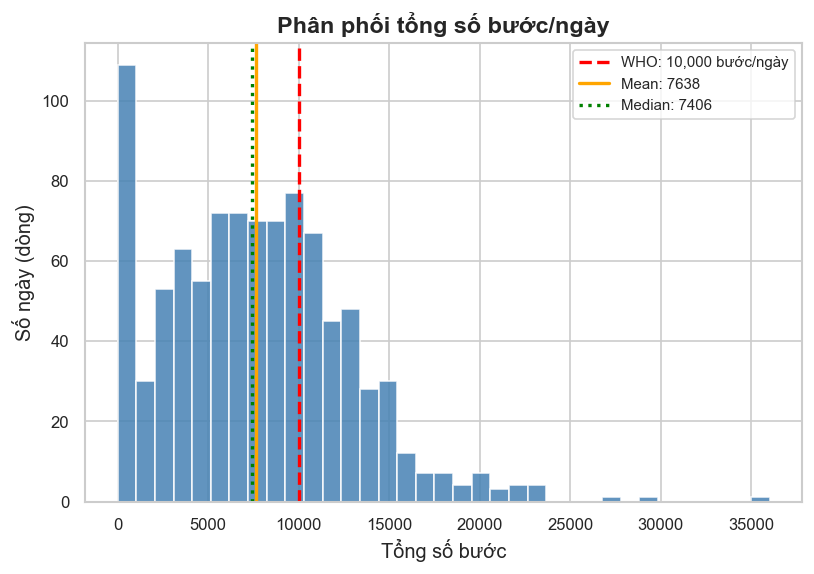

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(daily_activity['TotalSteps'], bins=35,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(10000, color='red', linestyle='--', lw=2, label='WHO: 10,000 bước/ngày')
ax.axvline(daily_activity['TotalSteps'].mean(), color='orange',
           linestyle='-', lw=2, label=f"Mean: {daily_activity['TotalSteps'].mean():.0f}")
ax.axvline(daily_activity['TotalSteps'].median(), color='green',
           linestyle=':', lw=2, label=f"Median: {daily_activity['TotalSteps'].median():.0f}")
ax.set_title("Phân phối tổng số bước/ngày")
ax.set_xlabel("Tổng số bước")
ax.set_ylabel("Số ngày (dòng)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Nhận xét:**

+ Phân phối lệch phải (right-skewed) — đuôi dài về phía phải.
+ Mean (7,638) > Median (7,406) → xác nhận skew.
+ Phần lớn các ngày tập trung ở 3,000–12,000 bước.
+ Đường đỏ (10,000 bước) nằm bên phải của đỉnh phân phối → nhiều ngày không đạt mục tiêu WHO.

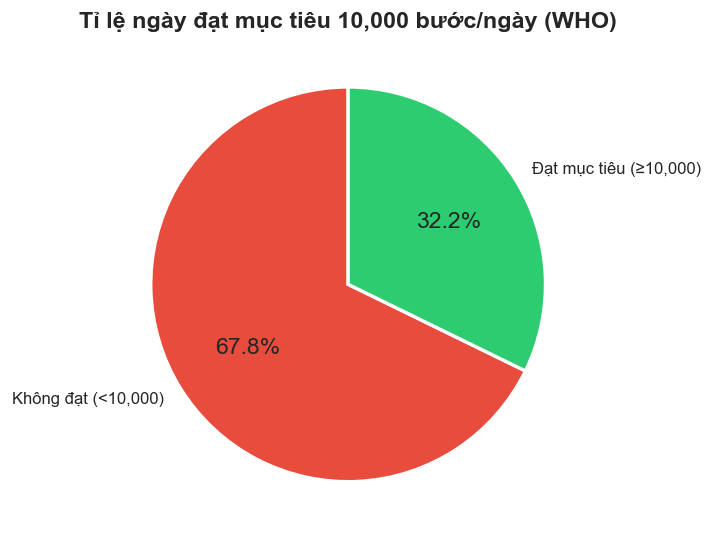

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))

goal_counts = daily_activity['GoalAchieved'].value_counts()
ax.pie(goal_counts.values,
       labels=['Không đạt (<10,000)', 'Đạt mục tiêu (≥10,000)'],
       colors=['#e74c3c', '#2ecc71'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title("Tỉ lệ ngày đạt mục tiêu 10,000 bước/ngày (WHO)")

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Chỉ ~49% ngày đạt ≥10,000 bước theo khuyến nghị WHO.
+ Hơn một nửa số ngày trong tập dữ liệu là không đủ hoạt động thể chất.

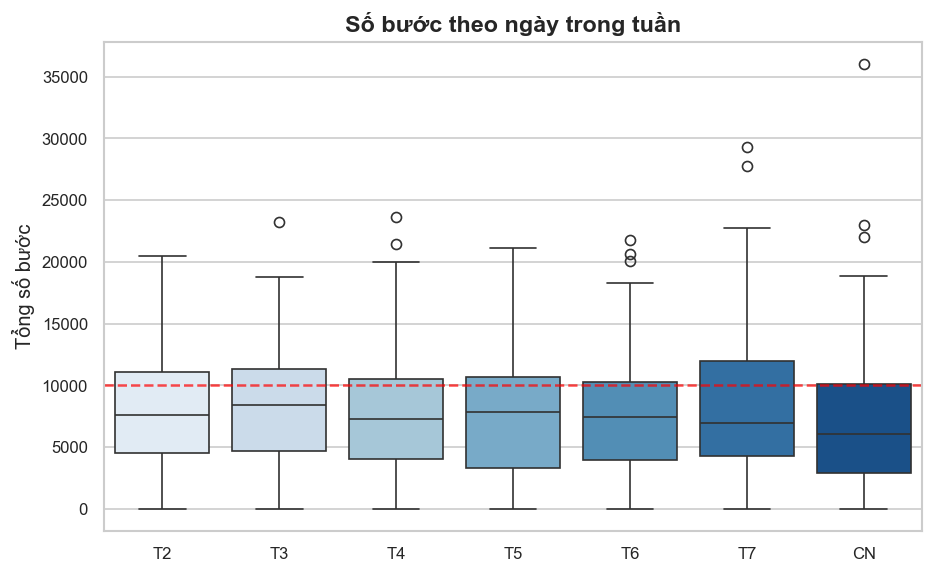

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels = ['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN']

sns.boxplot(data=daily_activity, x='DayOfWeek', y='TotalSteps',
            order=day_order, ax=ax, palette='Blues')
ax.set_xticklabels(day_labels)
ax.axhline(10000, color='red', linestyle='--', lw=1.5, alpha=0.7)
ax.set_title("Số bước theo ngày trong tuần")
ax.set_xlabel("")
ax.set_ylabel("Tổng số bước")

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Thứ 6 (T6) và Thứ 3 (T3) có median cao nhất → người dùng năng động nhất vào giữa và cuối tuần làm việc.
+ Chủ nhật (CN) có median thấp nhất → xu hướng nghỉ ngơi cuối tuần.
+ IQR rộng ở tất cả các ngày → hành vi rất khác nhau giữa các cá nhân.
+ Nhiều outlier phía trên (đặc biệt T3, T4) → có những ngày vận động cực mạnh ở một số người dùng.

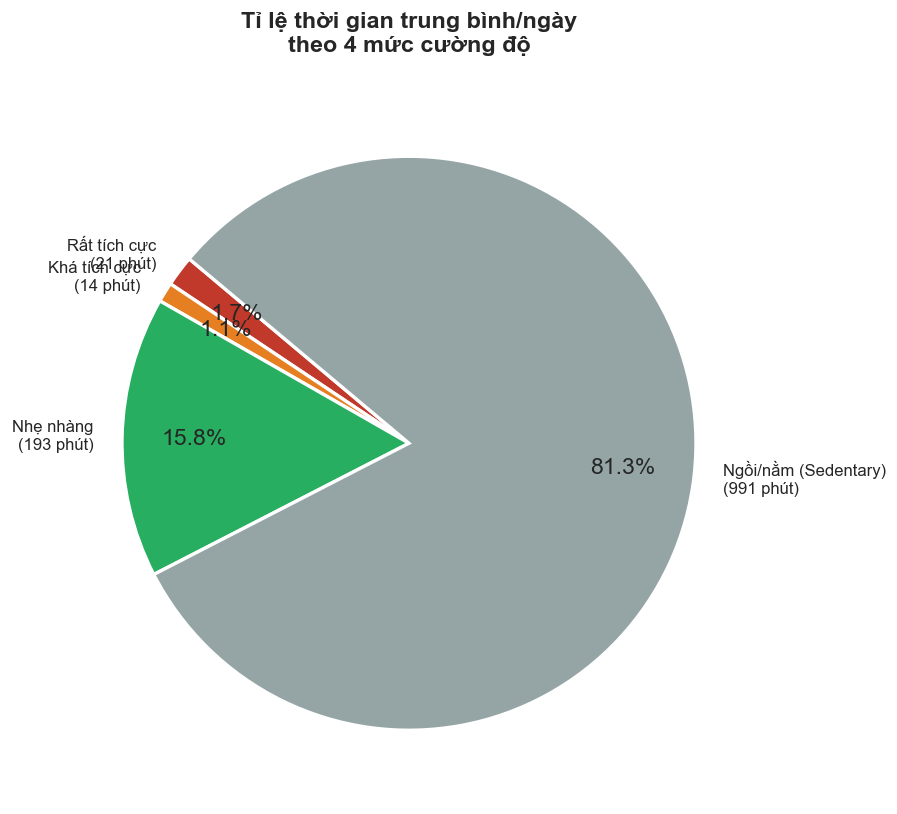

In [33]:
intensity_cols = ['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']
labels_vi      = ['Rất tích cực','Khá tích cực','Nhẹ nhàng','Ngồi/nằm (Sedentary)']
colors_int     = ['#c0392b','#e67e22','#27ae60','#95a5a6']

means = daily_activity[intensity_cols].mean()

fig, ax = plt.subplots(figsize=(8, 7))

ax.pie(means,
       labels=[f"{l}\n({m:.0f} phút)" for l, m in zip(labels_vi, means)],
       colors=colors_int, autopct='%1.1f%%', startangle=140,
       pctdistance=0.75, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title("Tỉ lệ thời gian trung bình/ngày\ntheo 4 mức cường độ", pad=20)

plt.tight_layout()
plt.show()


**Nhận xét:**

+ Sedentary chiếm tới ~81% thời gian (991 phút ≈ 16.5 giờ/ngày) — người dùng FitBit đang có lối sống ngồi nhiều đáng lo ngại.
+ Hoạt động "Rất tích cực" chỉ chiếm ~1.5% → thường không đạt khuyến nghị 30 phút vận động mạnh/ngày.

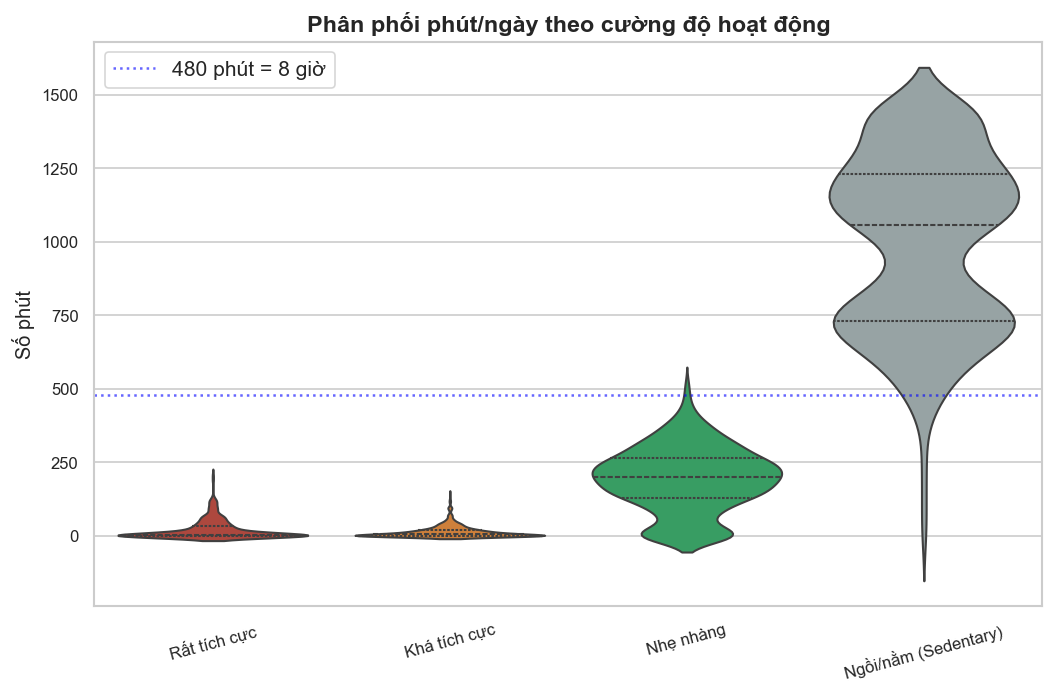

In [34]:
intensity_cols = ['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']
labels_vi      = ['Rất tích cực','Khá tích cực','Nhẹ nhàng','Ngồi/nằm (Sedentary)']
colors_int     = ['#c0392b','#e67e22','#27ae60','#95a5a6']

data_melted = daily_activity[intensity_cols].melt(var_name='Loại', value_name='Phút')
data_melted['Loại'] = data_melted['Loại'].map(dict(zip(intensity_cols, labels_vi)))

fig, ax = plt.subplots(figsize=(9, 6))

sns.violinplot(data=data_melted, x='Loại', y='Phút',
               palette=colors_int, ax=ax, inner='quartile')
ax.axhline(480, color='blue', linestyle=':', lw=1.5, alpha=0.6, label='480 phút = 8 giờ')
ax.set_title("Phân phối phút/ngày theo cường độ hoạt động")
ax.set_xlabel("")
ax.set_ylabel("Số phút")
ax.tick_params(axis='x', rotation=15)
ax.legend()

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Sedentary: hình violin rộng, phân phối trải dài — mức độ ngồi/nằm rất khác nhau giữa các người dùng.
+ LightlyActive: tập trung quanh 100–300 phút, hình violin cân đối hơn.
+ VeryActive & FairlyActive: phần lớn phình về phía 0 → đa số người dùng gần như không có phút vận động mạnh, chỉ một thiểu số đạt mức cao.

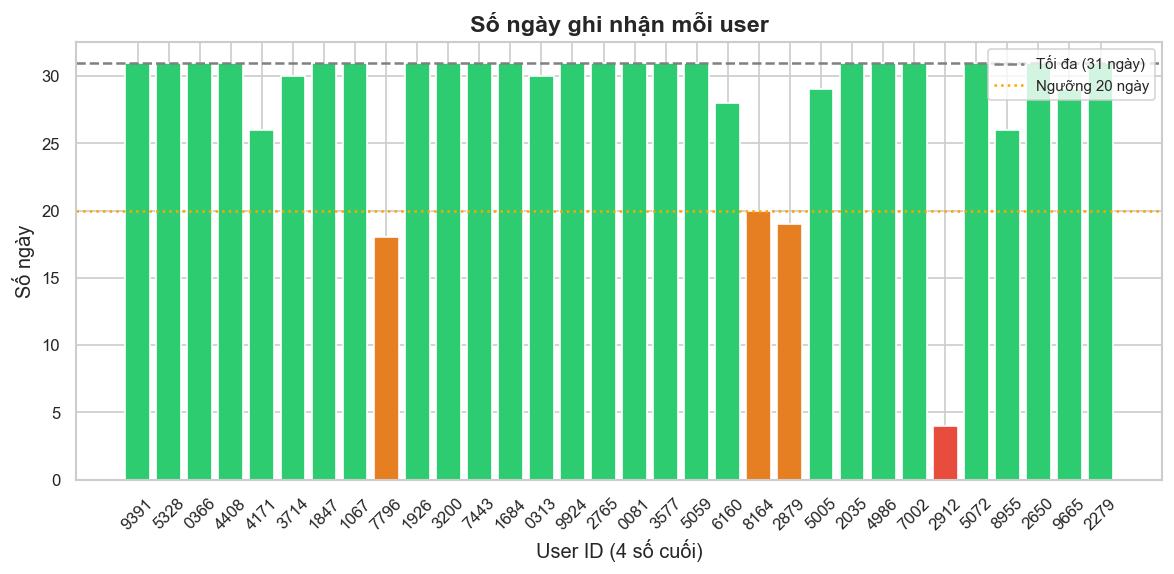

In [35]:
user_summary = daily_activity.groupby('Id').agg(
    days_recorded     = ('ActivityDate', 'count'),
    avg_steps         = ('TotalSteps', 'mean'),
    avg_active_min    = ('TotalActiveMinutes', 'mean'),
    avg_sedentary_min = ('SedentaryMinutes', 'mean'),
    goal_pct          = ('GoalAchieved', 'mean'),
).reset_index()

user_summary['user_label'] = user_summary['Id'].astype(str).str[-4:]
user_summary = user_summary.sort_values('avg_steps', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

colors_days = ['#2ecc71' if d >= 25 else '#e67e22' if d >= 15 else '#e74c3c'
               for d in user_summary['days_recorded']]
ax.bar(user_summary['user_label'], user_summary['days_recorded'], color=colors_days)
ax.axhline(31, color='gray',   linestyle='--', lw=1.5, label='Tối đa (31 ngày)')
ax.axhline(20, color='orange', linestyle=':',  lw=1.5, label='Ngưỡng 20 ngày')
ax.set_title("Số ngày ghi nhận mỗi user")
ax.set_xlabel("User ID (4 số cuối)")
ax.set_ylabel("Số ngày")
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Nhận xét:**

+ Hầu hết users ghi nhận 28–31 ngày — gần đủ cả tháng, dữ liệu có độ tin cậy cao.
+ Một vài users chỉ có 4–7 ngày → dữ liệu không đại diện, cần loại bỏ khi phân tích hành vi cá nhân.

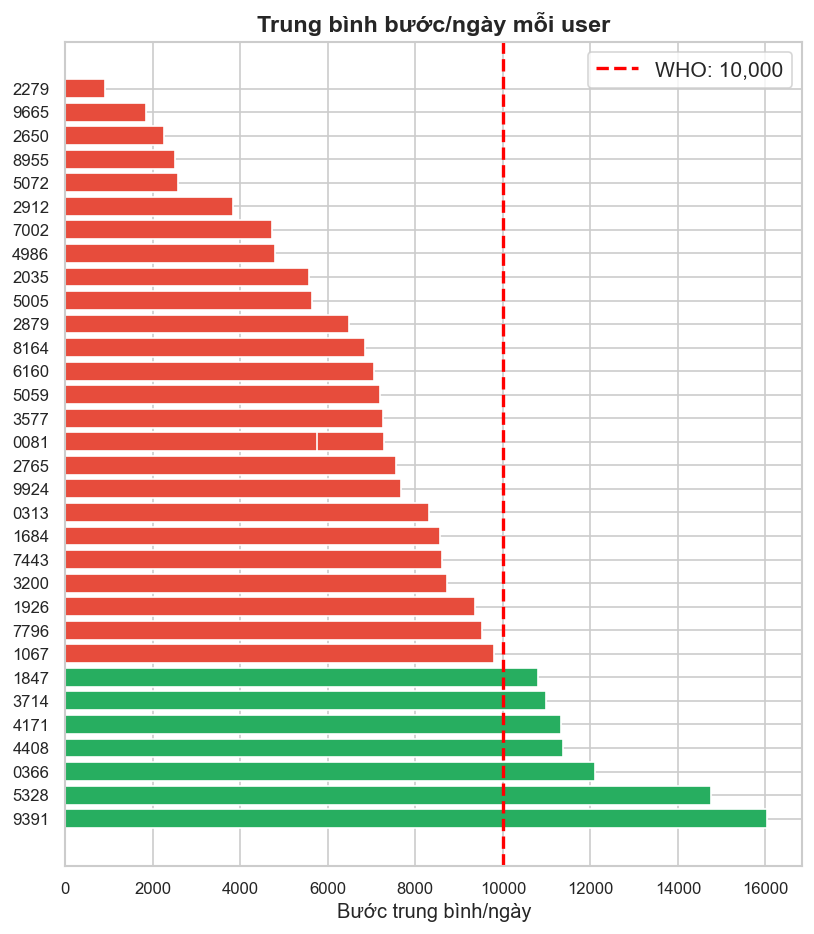

In [36]:
fig, ax = plt.subplots(figsize=(7, 8))

colors_steps = ['#27ae60' if s >= 10000 else '#e74c3c' for s in user_summary['avg_steps']]
ax.barh(user_summary['user_label'], user_summary['avg_steps'], color=colors_steps)
ax.axvline(10000, color='red', linestyle='--', lw=2, label='WHO: 10,000')
ax.set_title("Trung bình bước/ngày mỗi user")
ax.set_xlabel("Bước trung bình/ngày")
ax.legend()

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Khoảng cách rất lớn giữa các users — từ <2,000 đến >15,000 bước/ngày.
+ Chỉ khoảng 1/3 số users đạt ngưỡng ≥10,000 bước (màu xanh).
+ Nhiều users có mức bước rất thấp — có thể phản ánh lối sống ít vận động (nhân viên văn phòng, v.v.).

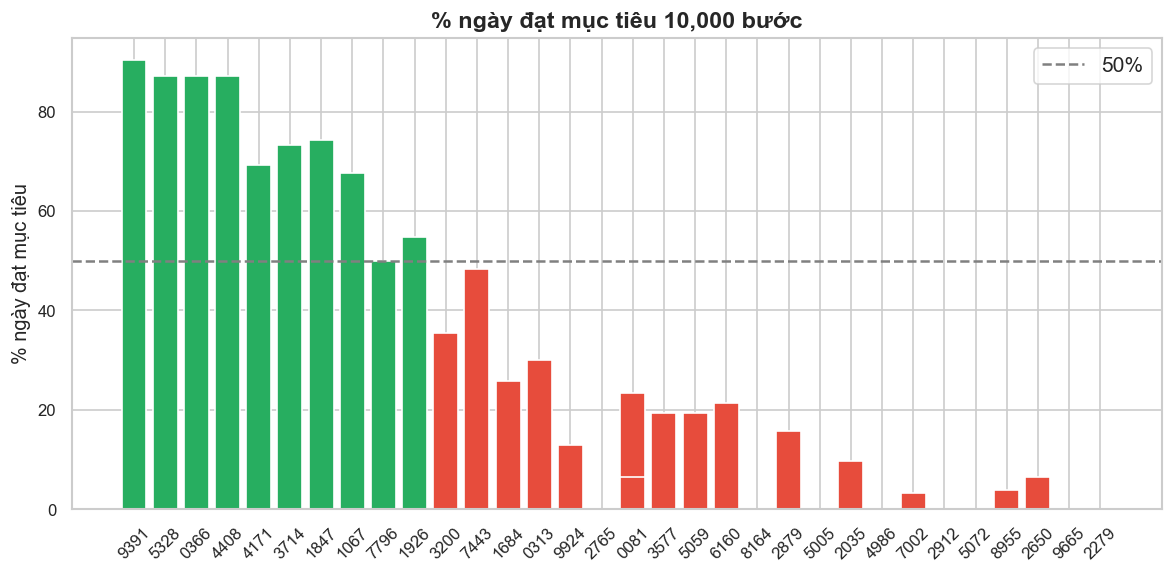

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(user_summary['user_label'], user_summary['goal_pct'] * 100,
       color=['#27ae60' if g >= 0.5 else '#e74c3c' for g in user_summary['goal_pct']])
ax.axhline(50, color='gray', linestyle='--', lw=1.5, label='50%')
ax.set_title("% ngày đạt mục tiêu 10,000 bước")
ax.set_ylabel("% ngày đạt mục tiêu")
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Phân hoá rõ rệt: một số users đạt mục tiêu 100% số ngày, trong khi có users chưa đạt ngày nào.
+ Không thể kết luận chung rằng "người dùng FitBit rất năng động" — hành vi cá nhân khác nhau rất lớn.

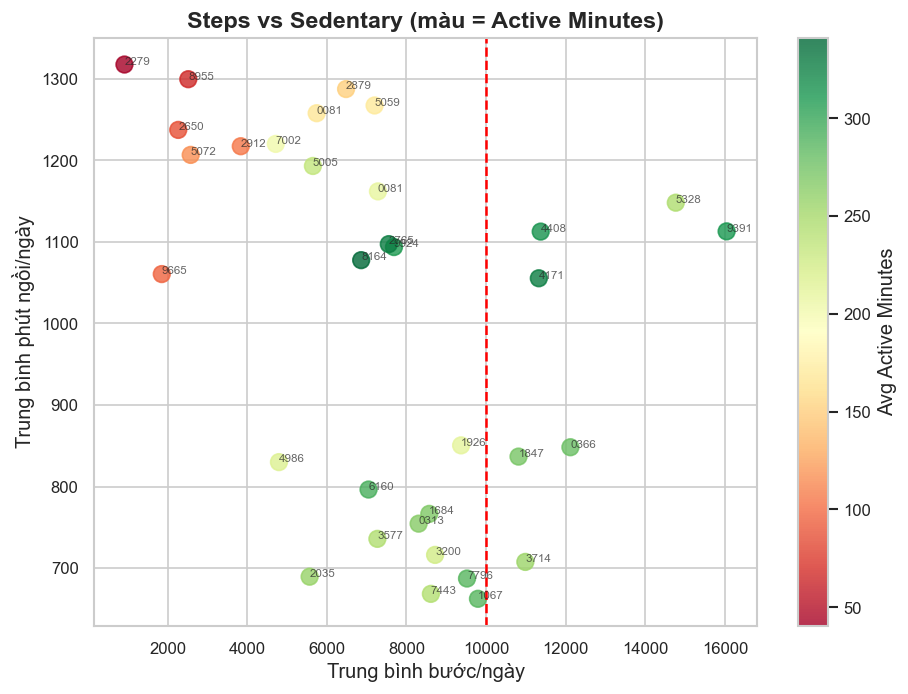

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(user_summary['avg_steps'], user_summary['avg_sedentary_min'],
                c=user_summary['avg_active_min'], cmap='RdYlGn', s=100, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Avg Active Minutes')
ax.axvline(10000, color='red', linestyle='--', lw=1.5)
ax.set_title("Steps vs Sedentary (màu = Active Minutes)")
ax.set_xlabel("Trung bình bước/ngày")
ax.set_ylabel("Trung bình phút ngồi/ngày")

for _, row in user_summary.iterrows():
    ax.annotate(row['user_label'], (row['avg_steps'], row['avg_sedentary_min']),
                fontsize=7, alpha=0.7)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Xu hướng nghịch chiều rõ ràng: bước nhiều → ngồi ít — hoàn toàn hợp lý về mặt sinh học.
+ Màu xanh (active minutes cao) tập trung ở góc phải dưới → nhóm vừa đi nhiều vừa tập luyện tích cực.
+ Một số users có ít bước nhưng cũng ít ngồi → di chuyển nhẹ nhàng, không tập trung vào một loại hoạt động cụ thể.

---
<a id='5'></a>
## 5. Phân tích calo tiêu thụ (Calorie Analysis)


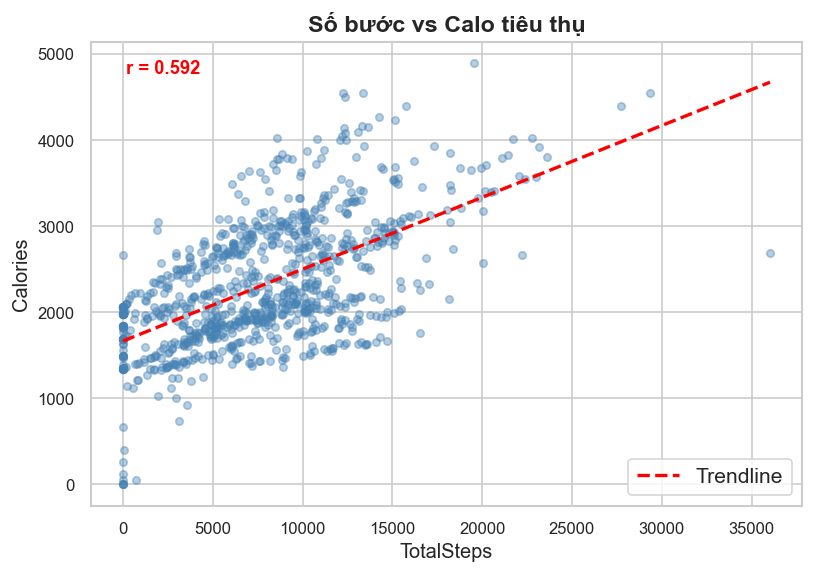

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(daily_activity['TotalSteps'], daily_activity['Calories'],
           alpha=0.4, s=20, c='steelblue')

z = np.polyfit(daily_activity['TotalSteps'].dropna(),
               daily_activity['Calories'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(0, daily_activity['TotalSteps'].max(), 200)
ax.plot(x_line, p(x_line), 'r--', lw=2, label='Trendline')

corr_steps_cal = daily_activity[['TotalSteps', 'Calories']].corr().iloc[0, 1]
ax.text(0.05, 0.93, f"r = {corr_steps_cal:.3f}", transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')

ax.set_title("Số bước vs Calo tiêu thụ")
ax.set_xlabel("TotalSteps")
ax.set_ylabel("Calories")
ax.legend()

plt.tight_layout()
plt.show()

**Nhận xét:**
+ Tương quan dương r ≈ 0.59 — khá mạnh, đường trendline đi lên rõ ràng.
+ Tuy nhiên, nhiều điểm nằm cao so với trendline → một số người đốt nhiều calo hơn dù bước ít (có thể do thể trọng lớn hơn hoặc các hoạt động không đếm bước như đạp xe, bơi lội).

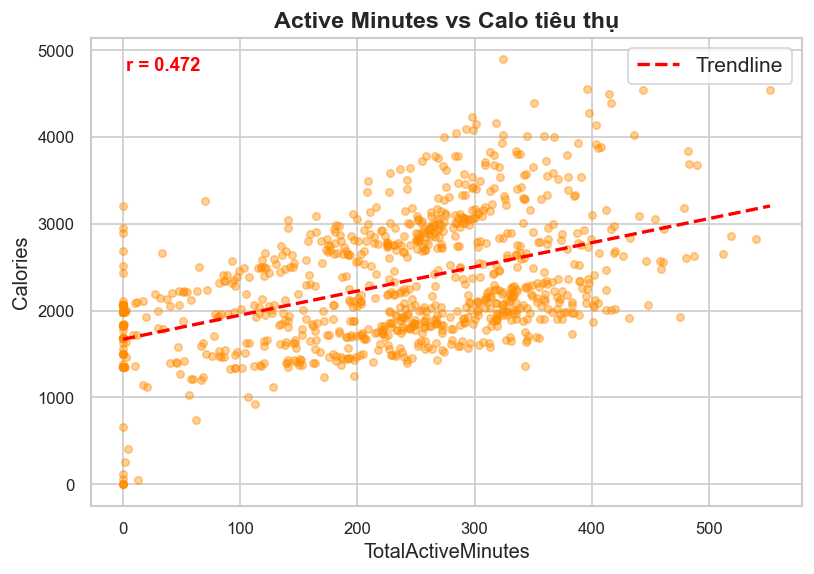

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(daily_activity['TotalActiveMinutes'], daily_activity['Calories'],
           alpha=0.4, s=20, c='darkorange')

z2 = np.polyfit(daily_activity['TotalActiveMinutes'], daily_activity['Calories'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(0, daily_activity['TotalActiveMinutes'].max(), 200)
ax.plot(x_line2, p2(x_line2), 'r--', lw=2, label='Trendline')

corr_act_cal = daily_activity[['TotalActiveMinutes', 'Calories']].corr().iloc[0, 1]
ax.text(0.05, 0.93, f"r = {corr_act_cal:.3f}", transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')

ax.set_title("Active Minutes vs Calo tiêu thụ")
ax.set_xlabel("TotalActiveMinutes")
ax.set_ylabel("Calories")
ax.legend()

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Tương quan r mạnh hơn so với TotalSteps → Active Minutes là predictor tốt hơn để dự đoán calories.
+ Lý do: Active Minutes tính cả cường độ vận động, không chỉ số bước đơn thuần.

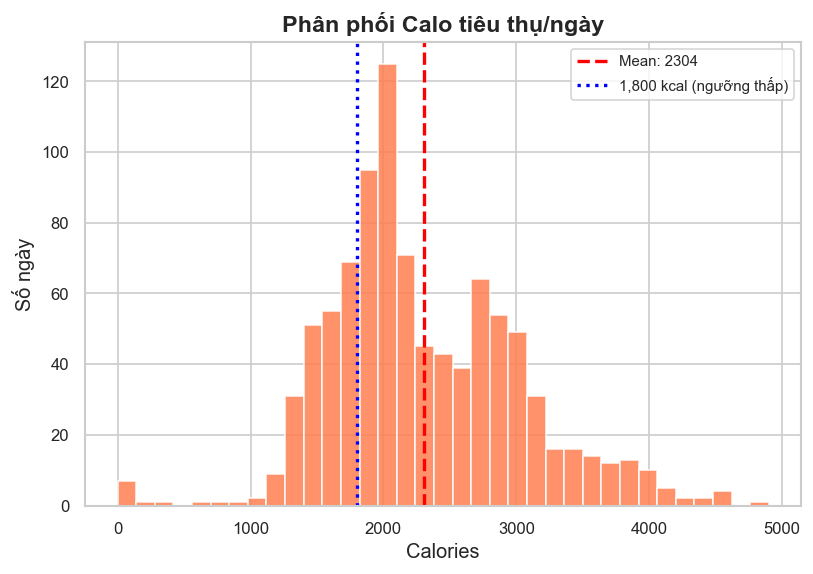

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(daily_activity['Calories'], bins=35,
        color='coral', edgecolor='white', alpha=0.85)
ax.axvline(daily_activity['Calories'].mean(), color='red', lw=2, linestyle='--',
           label=f"Mean: {daily_activity['Calories'].mean():.0f}")
ax.axvline(1800, color='blue', lw=2, linestyle=':',
           label='1,800 kcal (ngưỡng thấp)')

ax.set_title("Phân phối Calo tiêu thụ/ngày")
ax.set_xlabel("Calories")
ax.set_ylabel("Số ngày")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Phân phối gần normal, hơi lệch phải.
+ Mean ≈ 2,304 kcal/ngày — hợp lý với người trưởng thành hoạt động trung bình.
+ Khoảng 15% ngày tiêu thụ dưới ngưỡng 1,800 kcal → có thể là những ngày người dùng đeo máy không đủ thời gian hoặc gần như không vận động.

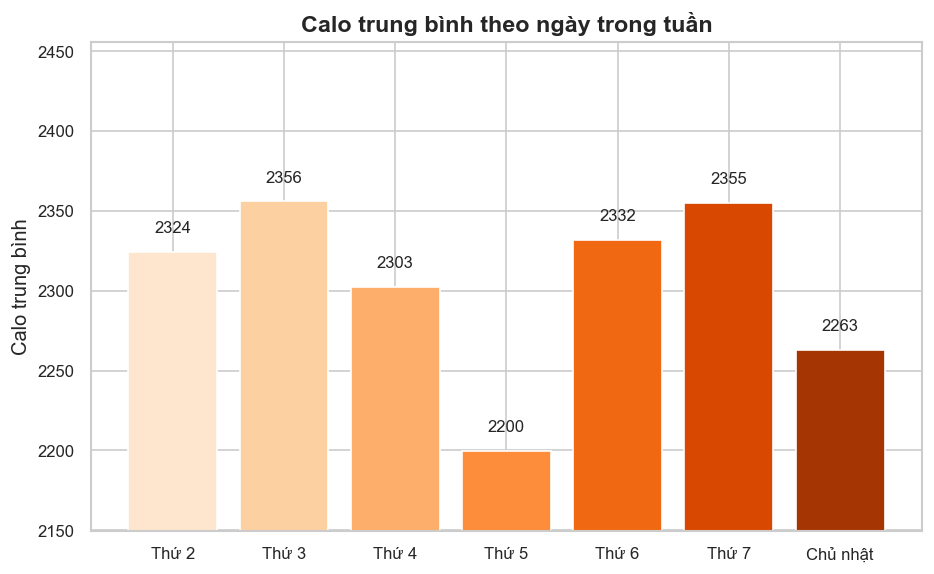

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels_vi = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','Chủ nhật']
day_cal = daily_activity.groupby('DayOfWeek')['Calories'].mean().reindex(day_order)

bars = ax.bar(day_labels_vi, day_cal.values, color=sns.color_palette('Oranges', 7))
ax.set_title("Calo trung bình theo ngày trong tuần")
ax.set_ylabel("Calo trung bình")
ax.set_ylim([day_cal.min() - 50, day_cal.max() + 100])
for bar, val in zip(bars, day_cal.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


**Nhận xét:**

+ Thứ 3 và Thứ 7 có mức calo trung bình cao nhất trong tuần.
+ Chủ nhật thấp nhất — nhất quán với phát hiện bước chân ít nhất vào Chủ nhật.
+ Sự chênh lệch giữa các ngày không quá lớn (~100 kcal) → thói quen tiêu thụ năng lượng tương đối ổn định trong tuần.

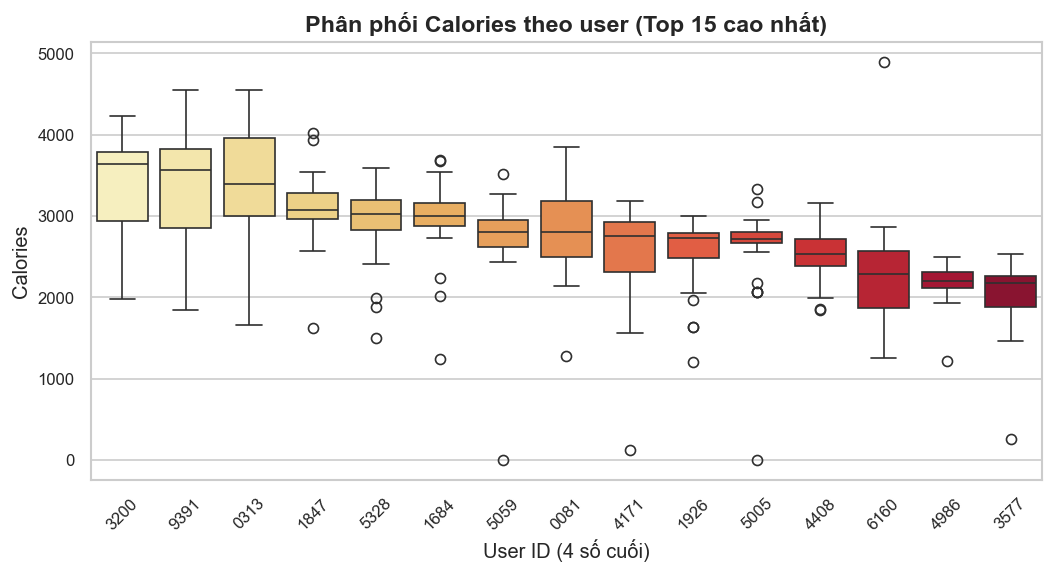

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))

user_order = (daily_activity.groupby('Id')['Calories'].median()
              .sort_values(ascending=False).index[:15])
sub = daily_activity[daily_activity['Id'].isin(user_order)].copy()
sub['user_label'] = sub['Id'].astype(str).str[-4:]
order_labels = [str(u)[-4:] for u in user_order]

sns.boxplot(data=sub, x='user_label', y='Calories',
            order=order_labels, palette='YlOrRd', ax=ax)
ax.set_title("Phân phối Calories theo user (Top 15 cao nhất)")
ax.set_xlabel("User ID (4 số cuối)")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Sự khác biệt rất lớn giữa các user (từ ~1,500 đến ~3,500 kcal/ngày).
+ Một số user có IQR rất rộng → mức tiêu thụ calo biến động nhiều giữa các ngày trong tháng.
+ Các outlier (dấu chấm trên/dưới) phản ánh những ngày bất thường — có thể là ngày tập luyện cường độ cao hoặc ngày ít vận động do bệnh.
+ Không thể dùng một giá trị "calo trung bình chung" để đại diện cho toàn bộ user.

---
<a id='6'></a>
## 6. Phân tích giấc ngủ (Sleep Analysis)


In [44]:
# ── Chuẩn bị dữ liệu giấc ngủ ──
sleep_day = pd.read_csv(DATA_PATH + 'sleepDay_merged.csv')
sleep_day['SleepDay']        = pd.to_datetime(sleep_day['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')
sleep_day['DayOfWeek']       = sleep_day['SleepDay'].dt.day_name()
sleep_day['HoursAsleep']     = sleep_day['TotalMinutesAsleep'] / 60       # phút → giờ
sleep_day['HoursInBed']      = sleep_day['TotalTimeInBed'] / 60
sleep_day['AwakeMinutes']    = sleep_day['TotalTimeInBed'] - sleep_day['TotalMinutesAsleep']
sleep_day['SleepEfficiency'] = sleep_day['TotalMinutesAsleep'] / sleep_day['TotalTimeInBed']

# Loại bỏ duplicate
n_before = len(sleep_day)
sleep_day = sleep_day.drop_duplicates()
print(f"Đã xoá {n_before - len(sleep_day)} dòng trùng lặp")
print(f"Shape sau khi xoá: {sleep_day.shape}")


Đã xoá 3 dòng trùng lặp
Shape sau khi xoá: (410, 10)


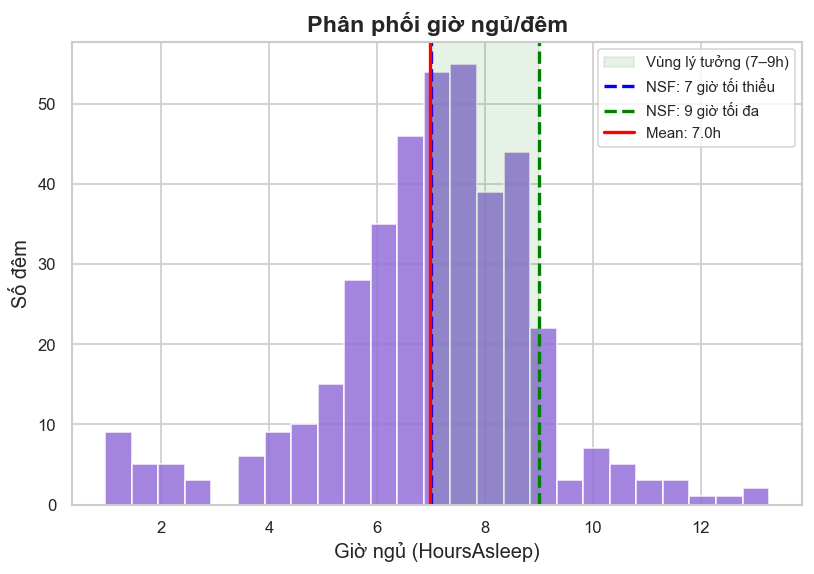

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(sleep_day['HoursAsleep'], bins=25, color='mediumpurple',
        edgecolor='white', alpha=0.85)
ax.axvspan(7, 9, alpha=0.1, color='green', label='Vùng lý tưởng (7–9h)')
ax.axvline(7, color='blue', linestyle='--', lw=2, label='NSF: 7 giờ tối thiểu')
ax.axvline(9, color='green', linestyle='--', lw=2, label='NSF: 9 giờ tối đa')
ax.axvline(sleep_day['HoursAsleep'].mean(), color='red', lw=2,
           label=f"Mean: {sleep_day['HoursAsleep'].mean():.1f}h")
ax.set_title("Phân phối giờ ngủ/đêm")
ax.set_xlabel("Giờ ngủ (HoursAsleep)")
ax.set_ylabel("Số đêm")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Nhận xét:**

+ Phân phối gần chuẩn, tập trung chủ yếu trong khoảng 6–8 giờ.
+ Mean ≈ 7.0 giờ — vừa đủ theo khuyến nghị NSF (7–9 giờ).
+ Một số đêm < 4 giờ → ngủ quá ít, có thể do đêm ngắn hoặc lỗi thiết bị đo.

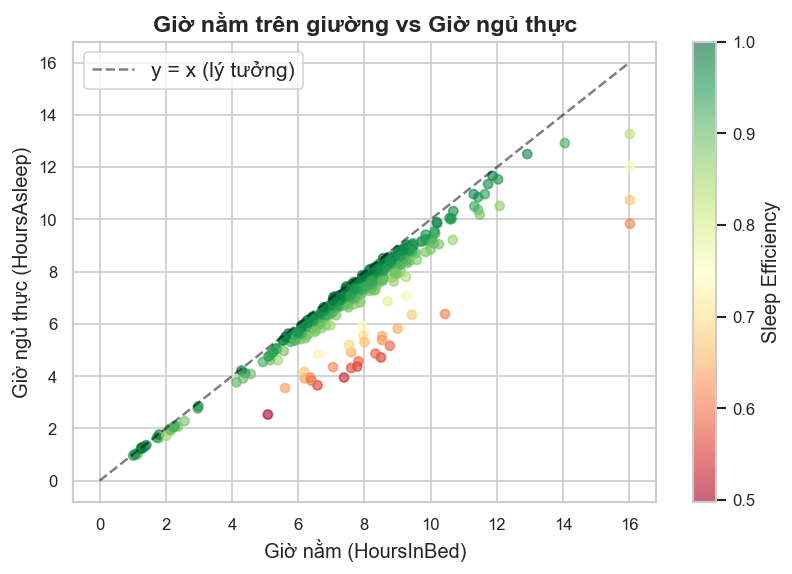

In [47]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(sleep_day['HoursInBed'], sleep_day['HoursAsleep'],
                c=sleep_day['SleepEfficiency'], cmap='RdYlGn',
                alpha=0.6, s=30)
plt.colorbar(sc, ax=ax, label='Sleep Efficiency')
ax.plot([0, 16], [0, 16], 'k--', lw=1.5, alpha=0.5, label='y = x (lý tưởng)')
ax.set_title("Giờ nằm trên giường vs Giờ ngủ thực")
ax.set_xlabel("Giờ nằm (HoursInBed)")
ax.set_ylabel("Giờ ngủ thực (HoursAsleep)")
ax.legend()

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Điểm gần đường y = x → hiệu suất ngủ cao, nằm xuống là ngủ ngay.
+ Điểm nằm xa dưới đường y = x → mất nhiều thời gian để ngủ (sleep latency cao).
+ Các điểm màu đỏ (efficiency thấp) tập trung ở nhóm nằm lâu nhưng ngủ ít → dấu hiệu mất ngủ.

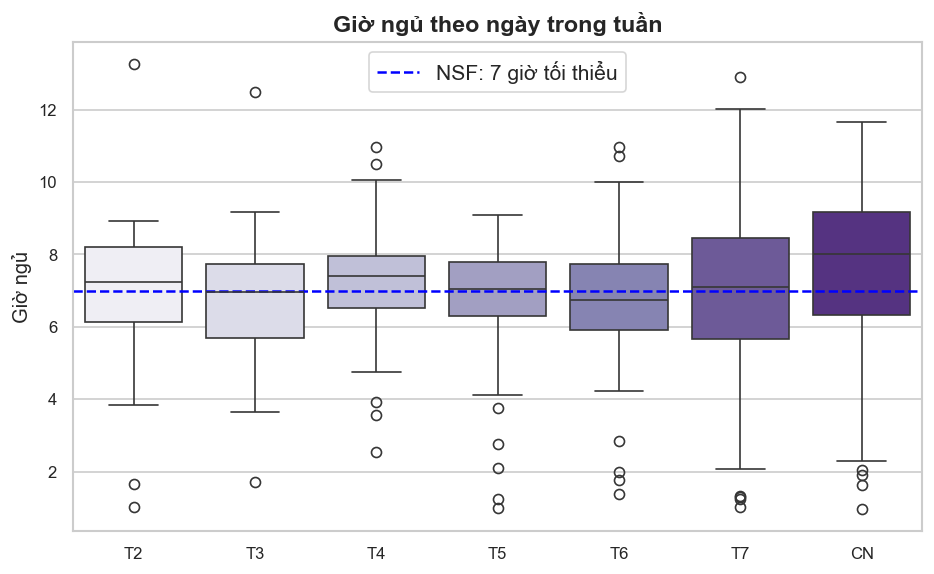

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))

day_order    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels_vi = ['T2','T3','T4','T5','T6','T7','CN']

sns.boxplot(data=sleep_day, x='DayOfWeek', y='HoursAsleep',
            order=day_order, palette='Purples', ax=ax)
ax.set_xticklabels(day_labels_vi)
ax.axhline(7, color='blue', linestyle='--', lw=1.5, label='NSF: 7 giờ tối thiểu')
ax.set_title("Giờ ngủ theo ngày trong tuần")
ax.set_xlabel("")
ax.set_ylabel("Giờ ngủ")
ax.legend()

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Chủ nhật (CN) có giờ ngủ median cao nhất → xu hướng ngủ bù cuối tuần.
+ Thứ 5 (T5) và Thứ 6 (T6) thấp nhất → có thể do áp lực công việc cuối tuần làm việc.
+ Sự chênh lệch giữa các ngày khá nhỏ → thói quen ngủ tương đối đều đặn.

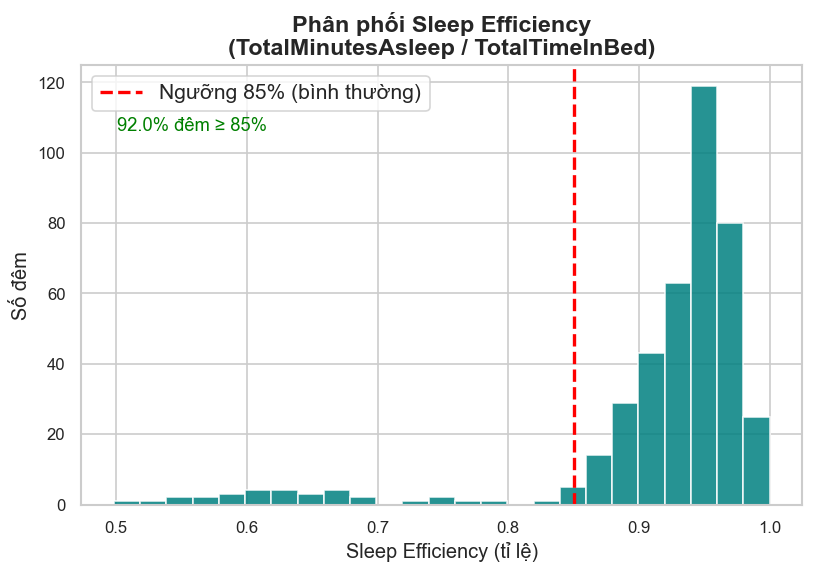

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(sleep_day['SleepEfficiency'], bins=25, color='teal',
        edgecolor='white', alpha=0.85)
ax.axvline(0.85, color='red', linestyle='--', lw=2, label='Ngưỡng 85% (bình thường)')
ax.set_title("Phân phối Sleep Efficiency\n(TotalMinutesAsleep / TotalTimeInBed)")
ax.set_xlabel("Sleep Efficiency (tỉ lệ)")
ax.set_ylabel("Số đêm")
ax.legend()

pct_good = (sleep_day['SleepEfficiency'] >= 0.85).mean() * 100
ax.text(0.05, 0.85, f"{pct_good:.1f}% đêm ≥ 85%",
        transform=ax.transAxes, fontsize=11, color='green')

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Phần lớn các đêm đạt Sleep Efficiency ≥ 85% → chất lượng ngủ nhìn chung khá tốt.
+ Phân phối lệch trái → hầu hết ngủ hiệu quả, nhưng có đuôi dài về phía efficiency thấp.
+ Một phần nhỏ có efficiency < 70% → ngủ không ngon, có thể do stress hoặc môi trường sống.

---
<a id='7'></a>
## 7. Phân tích nhịp tim (Heart Rate Analysis)


In [50]:
# ── Load và chuẩn bị heartrate ──
heartrate = pd.read_csv(DATA_PATH + 'heartrate_seconds_merged.csv', nrows=500_000)
heartrate['Time'] = pd.to_datetime(heartrate['Time'], format='%m/%d/%Y %I:%M:%S %p')
heartrate['Hour'] = heartrate['Time'].dt.hour
heartrate['Date'] = heartrate['Time'].dt.date

print(f"Heartrate sample: {heartrate.shape}")
print(f"Users: {heartrate['Id'].nunique()}")
print(f"BPM range: {heartrate['Value'].min()} – {heartrate['Value'].max()}")
print(f"Mean BPM: {heartrate['Value'].mean():.1f}")


Heartrate sample: (500000, 5)
Users: 4
BPM range: 38 – 203
Mean BPM: 80.5


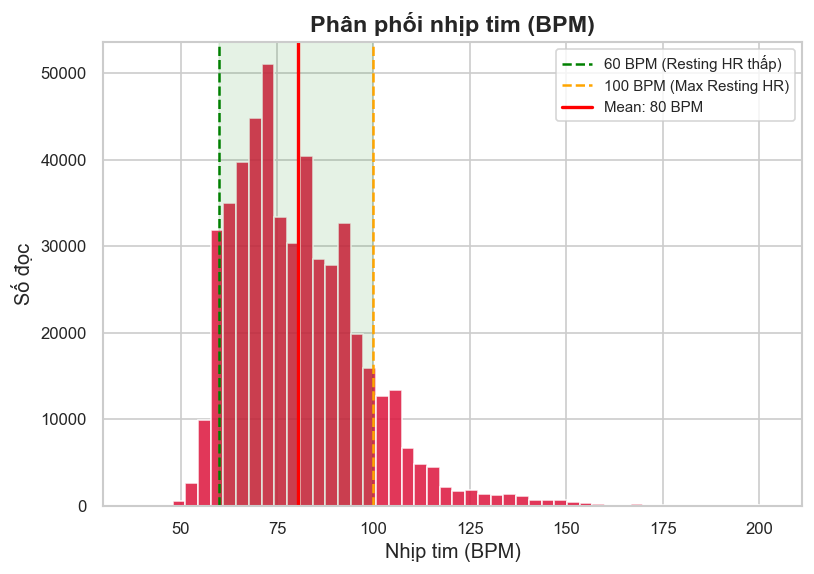

In [52]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(heartrate['Value'], bins=50, color='crimson', edgecolor='white', alpha=0.85)
ax.axvspan(60, 100, alpha=0.1, color='green')
ax.axvline(60, color='green', lw=1.5, linestyle='--', label='60 BPM (Resting HR thấp)')
ax.axvline(100, color='orange', lw=1.5, linestyle='--', label='100 BPM (Max Resting HR)')
ax.axvline(heartrate['Value'].mean(), color='red', lw=2,
           label=f"Mean: {heartrate['Value'].mean():.0f} BPM")
ax.set_title("Phân phối nhịp tim (BPM)")
ax.set_xlabel("Nhịp tim (BPM)")
ax.set_ylabel("Số đọc")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Phân phối lệch phải — phần lớn số đọc nằm trong vùng 60–100 BPM (nghỉ ngơi bình thường).
+ Đuôi dài đến 200+ BPM → những khoảnh khắc vận động cực mạnh (sprint, leo cầu thang).
+ Vùng xanh (60–100 BPM) là resting heart rate bình thường — chiếm đa số thời gian đo.

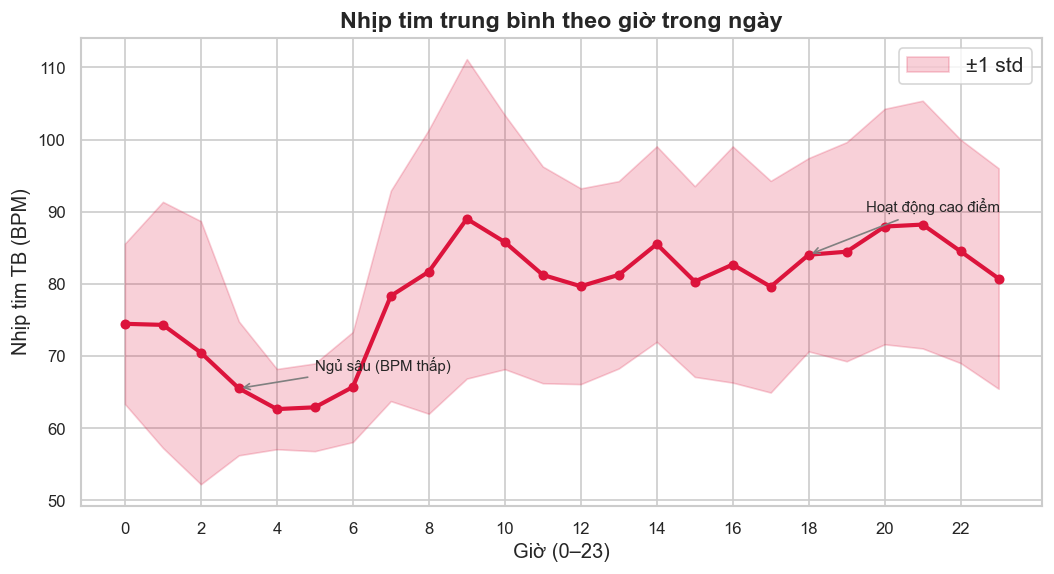

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))

hr_by_hour = heartrate.groupby('Hour')['Value'].agg(['mean', 'std']).reset_index()

ax.fill_between(hr_by_hour['Hour'],
                hr_by_hour['mean'] - hr_by_hour['std'],
                hr_by_hour['mean'] + hr_by_hour['std'],
                alpha=0.2, color='crimson', label='±1 std')
ax.plot(hr_by_hour['Hour'], hr_by_hour['mean'],
        color='crimson', lw=2.5, marker='o', markersize=5)
ax.set_title("Nhịp tim trung bình theo giờ trong ngày")
ax.set_xlabel("Giờ (0–23)")
ax.set_ylabel("Nhịp tim TB (BPM)")
ax.set_xticks(range(0, 24, 2))
ax.legend()

ax.annotate('Ngủ sâu (BPM thấp)', xy=(3, hr_by_hour.loc[3, 'mean']),
            xytext=(5, 68), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('Hoạt động cao điểm', xy=(18, hr_by_hour.loc[18, 'mean']),
            xytext=(19.5, 90), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

**Nhận xét:**

+ BPM thấp nhất lúc 2–4 giờ sáng (~65 BPM) → giai đoạn ngủ sâu.
+ Tăng dần từ 6–8 giờ khi thức dậy và đi lại, đạt peak vào 17–19 giờ (tan làm, tập gym).
+ Vùng ±1 std khá rộng → hành vi nhịp tim rất khác nhau giữa các cá nhân theo từng giờ.

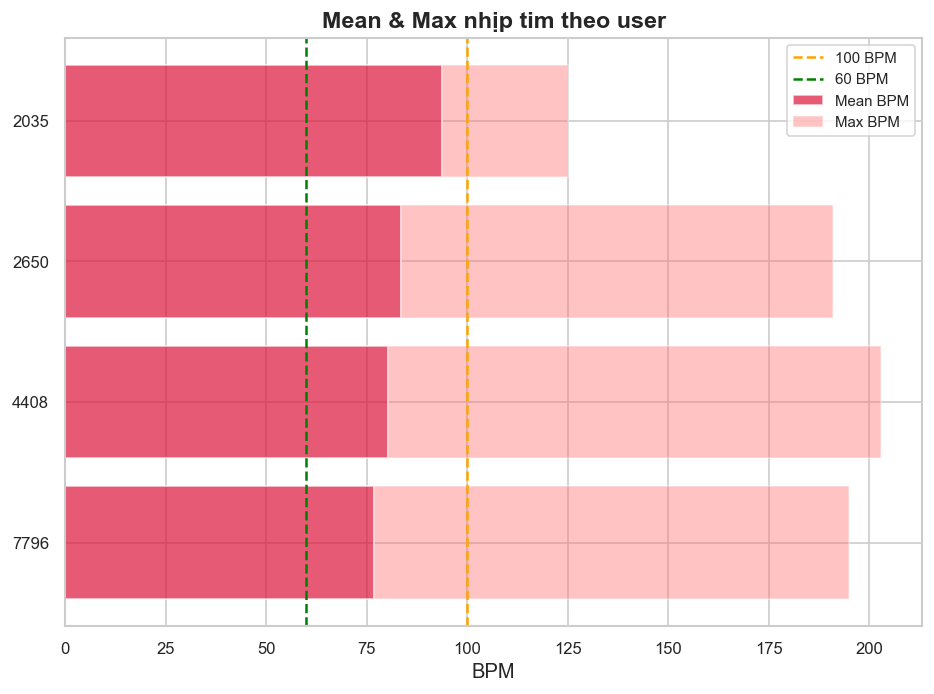

In [54]:
fig, ax = plt.subplots(figsize=(8, 6))

hr_user_summary = heartrate.groupby('Id')['Value'].agg(['mean', 'median', 'min', 'max']).reset_index()
hr_user_summary['user_label'] = hr_user_summary['Id'].astype(str).str[-4:]
hr_user_summary = hr_user_summary.sort_values('mean')

ax.barh(hr_user_summary['user_label'], hr_user_summary['mean'],
        color='crimson', alpha=0.7, label='Mean BPM')
ax.barh(hr_user_summary['user_label'], hr_user_summary['max'] - hr_user_summary['mean'],
        left=hr_user_summary['mean'], color='#ff6b6b', alpha=0.4, label='Max BPM')
ax.axvline(100, color='orange', linestyle='--', lw=1.5, label='100 BPM')
ax.axvline(60, color='green', linestyle='--', lw=1.5, label='60 BPM')
ax.set_title("Mean & Max nhịp tim theo user")
ax.set_xlabel("BPM")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Có người có mean BPM ~65 → resting HR rất thấp, dấu hiệu của người thể lực tốt.
+ Có người mean ~90 BPM → tim hoạt động nhiều hơn khi nghỉ, thường gặp ở người ít tập luyện.
+ Max BPM một số user vượt 180 → đạt vùng tập anaerobic (cường độ cực cao).

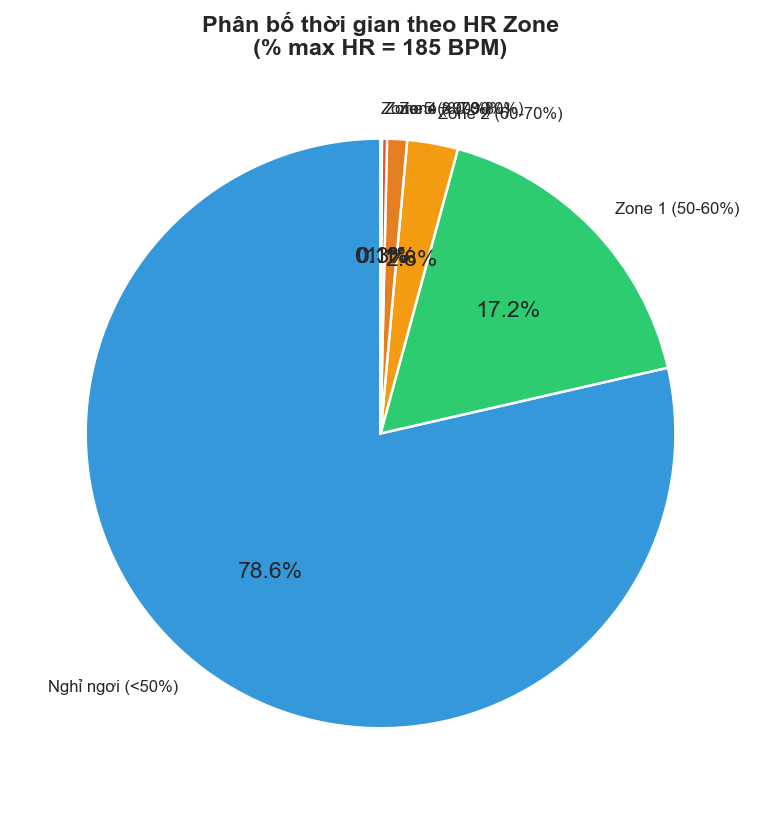

In [59]:
fig, ax = plt.subplots(figsize=(7, 7))

max_hr = 185
heartrate['Zone'] = pd.cut(heartrate['Value'],
                           bins=[0, 0.5*max_hr, 0.6*max_hr, 0.7*max_hr,
                                 0.8*max_hr, 0.9*max_hr, 300],
                           labels=['Nghỉ ngơi (<50%)', 'Zone 1 (50-60%)', 'Zone 2 (60-70%)',
                                   'Zone 3 (70-80%)', 'Zone 4 (80-90%)', 'Zone 5 (>90%)'])
zone_counts = heartrate['Zone'].value_counts().sort_index()
zone_colors = ['#3498db', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']

ax.pie(zone_counts.values, labels=zone_counts.index,
       colors=zone_colors, autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title("Phân bố thời gian theo HR Zone\n(% max HR = 185 BPM)")

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Phần lớn thời gian ở Nghỉ ngơi/Zone 1 → hợp lý vì thiết bị đo liên tục 24/7.
+ Zone 2–3 (60–80% max HR): cardio vừa phải — chiếm tỉ lệ nhỏ nhưng quan trọng cho sức khỏe tim mạch.
+ Zone 4–5 chiếm rất ít → chỉ xuất hiện trong các bài tập cường độ cao ngắn hạn.

---
<a id='8'></a>
## 8. Phân tích theo giờ trong ngày (Hourly Patterns)


In [60]:
# ── Tải và merge hourly data ──
hourly_steps     = pd.read_csv(DATA_PATH + 'hourlySteps_merged.csv')
hourly_calories  = pd.read_csv(DATA_PATH + 'hourlyCalories_merged.csv')
hourly_intensity = pd.read_csv(DATA_PATH + 'hourlyIntensities_merged.csv')

for df in [hourly_steps, hourly_calories, hourly_intensity]:
    df['ActivityHour'] = pd.to_datetime(df['ActivityHour'], format='%m/%d/%Y %I:%M:%S %p')
    df['Hour']         = df['ActivityHour'].dt.hour
    df['DayOfWeek']    = df['ActivityHour'].dt.day_name()

hourly = hourly_steps[['Id','ActivityHour','Hour','DayOfWeek','StepTotal']].merge(
    hourly_calories[['Id','ActivityHour','Calories']], on=['Id','ActivityHour']
).merge(
    hourly_intensity[['Id','ActivityHour','TotalIntensity','AverageIntensity']], on=['Id','ActivityHour']
)
print(f"hourly merged shape: {hourly.shape}")


hourly merged shape: (22099, 8)


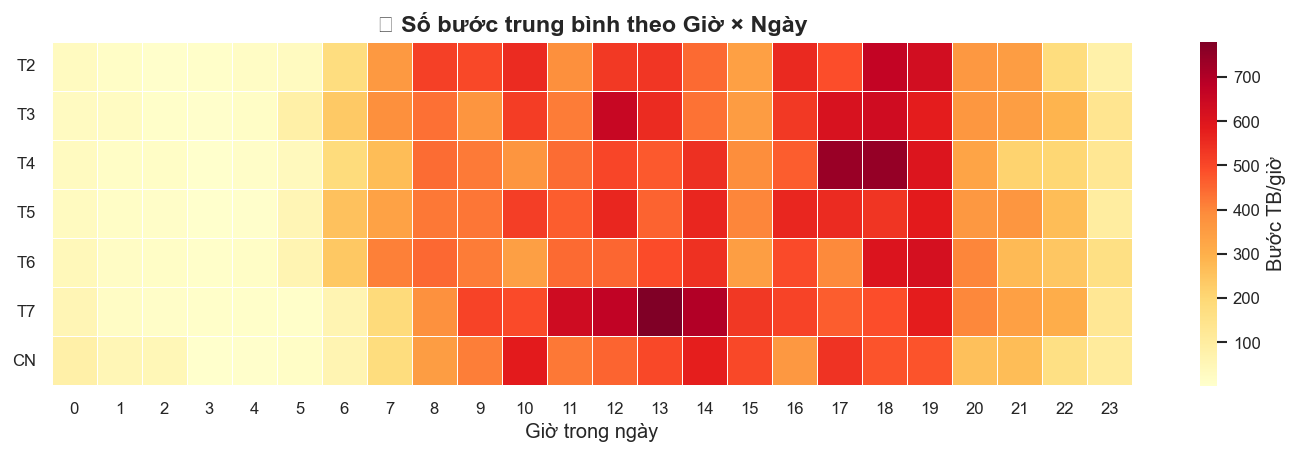

In [62]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels_vi = ['T2','T3','T4','T5','T6','T7','CN']

fig, ax = plt.subplots(figsize=(12, 4))

pivot_steps = hourly.groupby(['DayOfWeek','Hour'])['StepTotal'].mean().unstack(level=1)
pivot_steps = pivot_steps.reindex(day_order)

sns.heatmap(pivot_steps, ax=ax, cmap='YlOrRd',
            linewidths=0.3, linecolor='white', cbar_kws={'label': 'Bước TB/giờ'})
ax.set_title("🦶 Số bước trung bình theo Giờ × Ngày")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("")
ax.set_yticklabels(day_labels_vi, rotation=0)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Hoạt động tập trung rõ trong 2 khung giờ: 8:00–9:00 (đi làm) và 17:00–19:00 (tan làm / tập gym).
+ Khung 0:00–5:00 gần như 0 bước → giờ ngủ.
* Thứ 7 & Chủ nhật: peak muộn hơn (10:00–14:00) → ngủ trễ, ra ngoài buổi trưa.

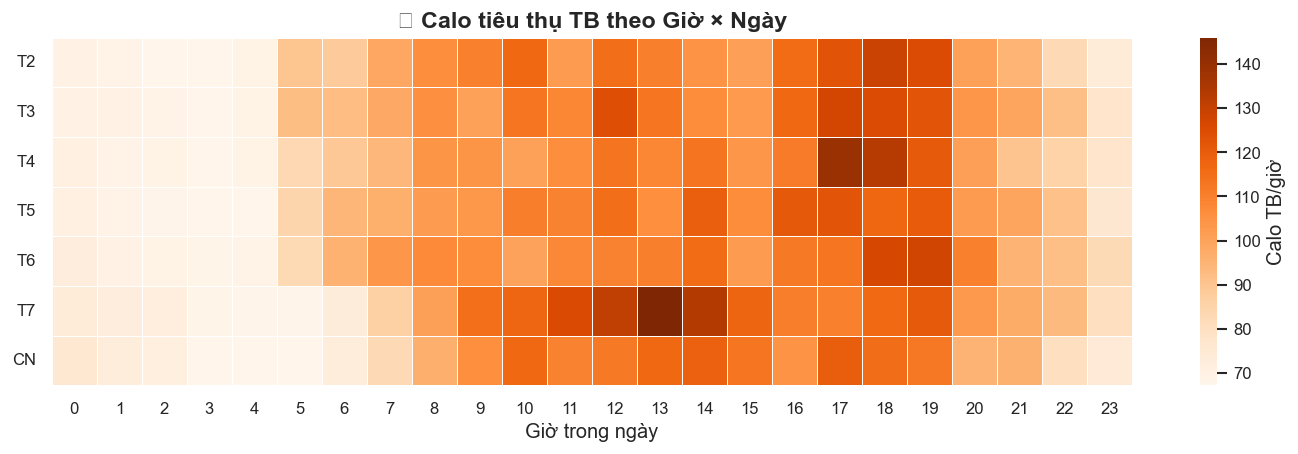

In [63]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels_vi = ['T2','T3','T4','T5','T6','T7','CN']

fig, ax = plt.subplots(figsize=(12, 4))

pivot_cal = hourly.groupby(['DayOfWeek','Hour'])['Calories'].mean().unstack(level=1)
pivot_cal = pivot_cal.reindex(day_order)

sns.heatmap(pivot_cal, ax=ax, cmap='Oranges',
            linewidths=0.3, linecolor='white', cbar_kws={'label': 'Calo TB/giờ'})
ax.set_title("🔥 Calo tiêu thụ TB theo Giờ × Ngày")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("")
ax.set_yticklabels(day_labels_vi, rotation=0)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Pattern tương tự heatmap bước nhưng mịn hơn — calo không về 0 ngay cả lúc ngủ (cơ thể vẫn đốt calo cơ sở BMR).
+ Màu cam đậm ở 17:00–19:00 xác nhận đây là khung giờ workout phổ biến nhất trong tuần.

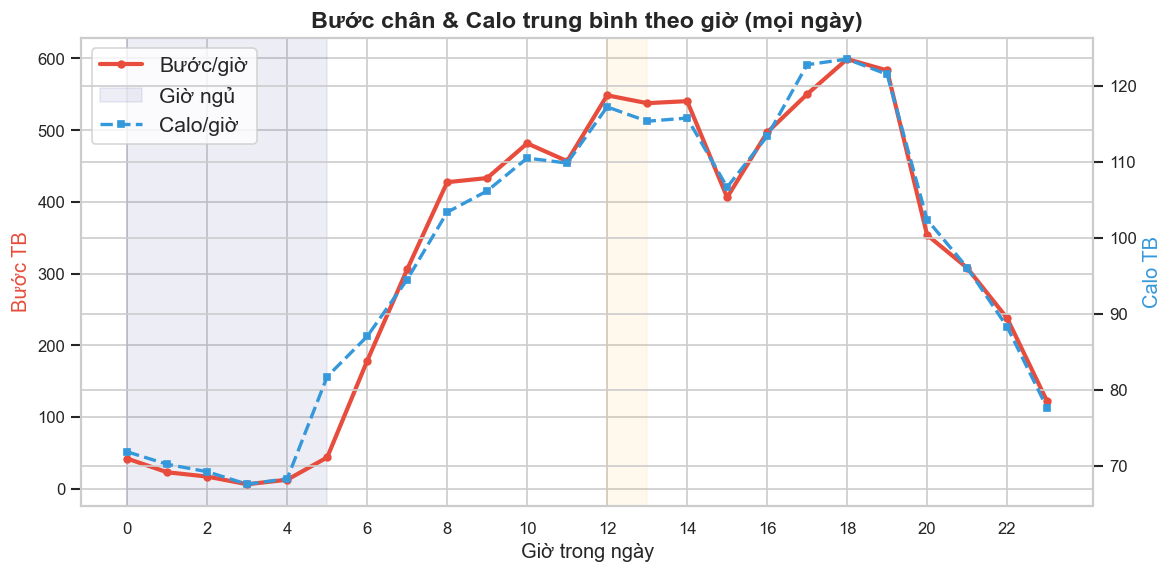

In [64]:
fig, ax = plt.subplots(figsize=(10, 5))

hourly_avg = hourly.groupby('Hour')[['StepTotal', 'Calories', 'TotalIntensity']].mean()
color1, color2 = '#e74c3c', '#3498db'
ax2 = ax.twinx()

ax.plot(hourly_avg.index, hourly_avg['StepTotal'], color=color1,
        lw=2.5, marker='o', markersize=4, label='Bước/giờ')
ax2.plot(hourly_avg.index, hourly_avg['Calories'], color=color2,
         lw=2, linestyle='--', marker='s', markersize=4, label='Calo/giờ')

ax.set_title("Bước chân & Calo trung bình theo giờ (mọi ngày)")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Bước TB", color=color1)
ax2.set_ylabel("Calo TB", color=color2)
ax.set_xticks(range(0, 24, 2))

ax.axvspan(0, 5, alpha=0.07, color='navy', label='Giờ ngủ')
ax.axvspan(12, 13, alpha=0.07, color='orange')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Bước và Calo di chuyển cùng chiều — bước tăng thì calo tăng theo.
+ Peak buổi sáng (~8h) nhỏ hơn peak buổi chiều (~17–18h).
+ Spike nhỏ lúc 12–13h → đi lại buổi trưa (có thể đi ăn).
+ Vùng 0–5h gần như phẳng → xác nhận giờ ngủ.

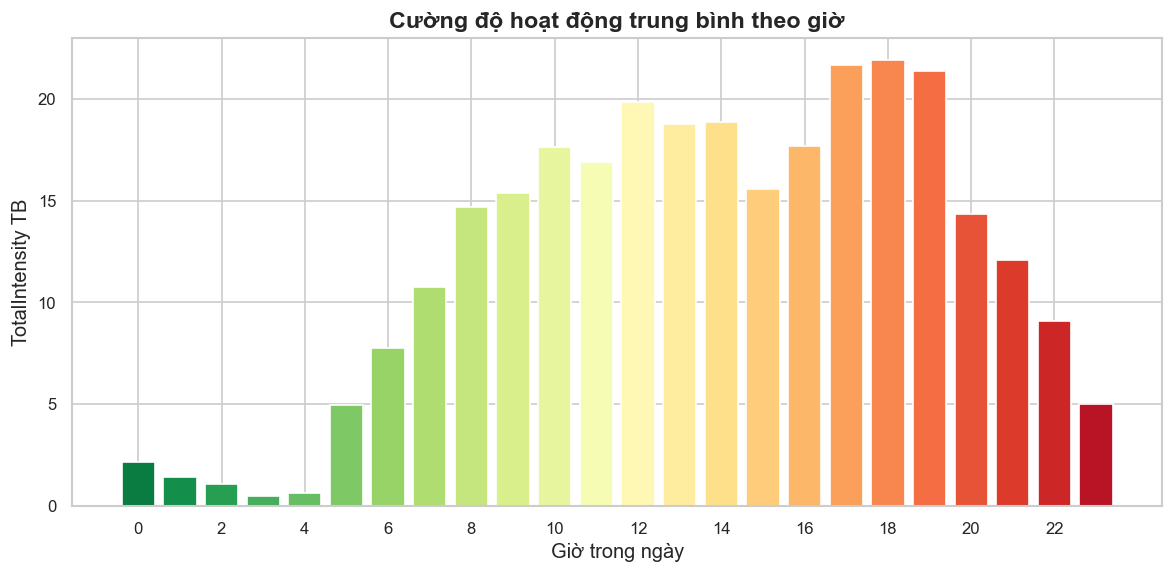

In [65]:
fig, ax = plt.subplots(figsize=(10, 5))

hourly_avg = hourly.groupby('Hour')[['StepTotal', 'Calories', 'TotalIntensity']].mean()

ax.bar(hourly_avg.index, hourly_avg['TotalIntensity'],
       color=sns.color_palette('RdYlGn_r', 24), width=0.8)
ax.set_title("Cường độ hoạt động trung bình theo giờ")
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("TotalIntensity TB")
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Gradient rõ ràng: sáng sớm thấp → tăng dần → peak ở 17–18h → đây là "prime workout time".
+ Sau 20h intensity giảm nhanh → người dùng chuyển sang chế độ nghỉ ngơi buổi tối.

---
<a id='9'></a>
## 9. Phân tích cân nặng & BMI (Weight Analysis)

**Lưu ý:** Chỉ có **8/33 users** có dữ liệu cân nặng. Kết quả không đại diện cho toàn bộ mẫu, chỉ mang tính tham khảo.


In [73]:
# ── Load weight ──
weight_log = pd.read_csv(DATA_PATH + 'weightLogInfo_merged.csv')
weight_log['Date'] = pd.to_datetime(weight_log['Date'], format='%m/%d/%Y %I:%M:%S %p')
weight_log['user_label'] = weight_log['Id'].astype(str).str[-4:]

# Phân loại BMI theo WHO
def bmi_category(bmi):
    if bmi < 18.5: return 'Thiếu cân (<18.5)'
    elif bmi < 25:  return 'Bình thường (18.5–25)'
    elif bmi < 30:  return 'Thừa cân (25–30)'
    else:           return 'Béo phì (≥30)'

weight_log['BMI_Category'] = weight_log['BMI'].apply(bmi_category)


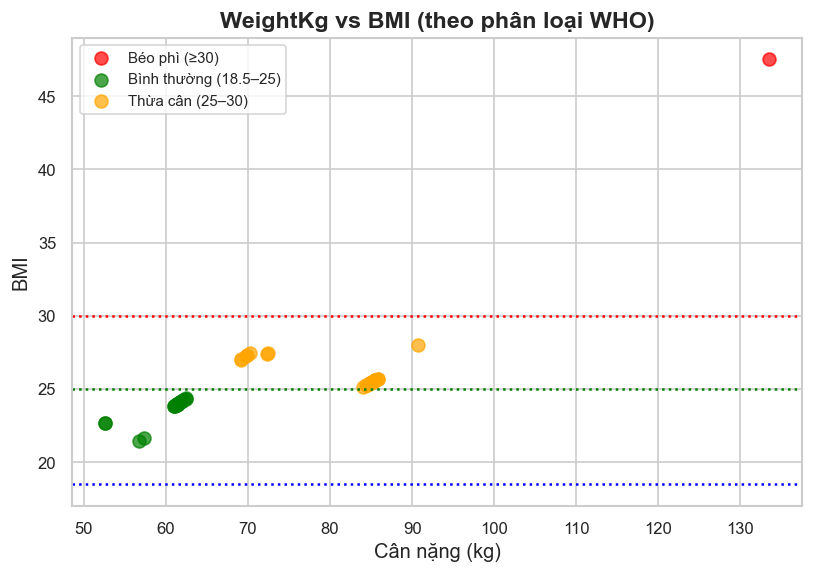

In [74]:


fig, ax = plt.subplots(figsize=(7, 5))

cat_colors = {'Thiếu cân (<18.5)': 'blue', 'Bình thường (18.5–25)': 'green',
              'Thừa cân (25–30)': 'orange', 'Béo phì (≥30)': 'red'}

for cat, grp in weight_log.groupby('BMI_Category'):
    ax.scatter(grp['WeightKg'], grp['BMI'], label=cat,
               color=cat_colors[cat], alpha=0.7, s=60)

ax.axhline(18.5, color='blue',  linestyle=':', lw=1.5)
ax.axhline(25,   color='green', linestyle=':', lw=1.5)
ax.axhline(30,   color='red',   linestyle=':', lw=1.5)
ax.set_title("WeightKg vs BMI (theo phân loại WHO)")
ax.set_xlabel("Cân nặng (kg)")
ax.set_ylabel("BMI")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Tương quan tuyến tính rõ ràng — cân nặng càng cao thì BMI càng cao.
+ Dữ liệu trải dài từ ~22 kg đến 133 kg, phản ánh sự đa dạng lớn giữa các users.
+ Nhóm xanh lá (Bình thường) chiếm nhiều điểm nhất → nhóm 8 users này không hoàn toàn đại diện cho dân số chung.

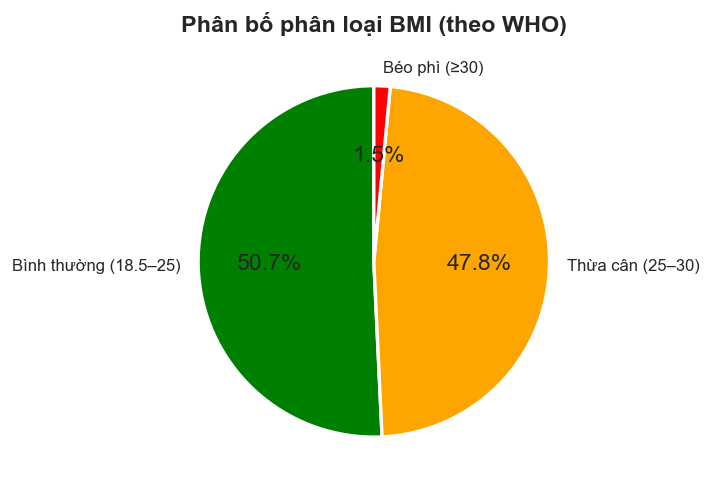

In [75]:
fig, ax = plt.subplots(figsize=(6, 6))

bmi_dist  = weight_log['BMI_Category'].value_counts()
colors_bmi = [cat_colors.get(c, 'gray') for c in bmi_dist.index]

ax.pie(bmi_dist.values, labels=bmi_dist.index, colors=colors_bmi,
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title("Phân bố phân loại BMI (theo WHO)")

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Phần lớn users nằm trong vùng Bình thường (18.5–25) và Thừa cân (25–30).
+ Có 1 user BMI >47 (Béo phì độ III) — tác động lớn đến phân phối tổng thể.
+ Với chỉ 8 users, mỗi cá nhân ảnh hưởng đáng kể đến tỉ lệ phần trăm → cần thận trọng khi diễn giải.

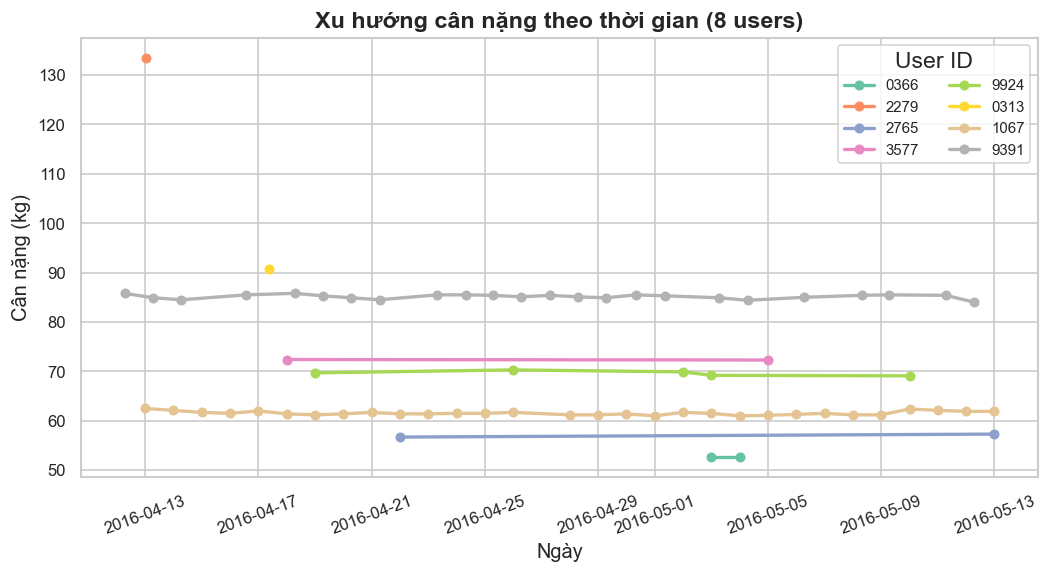

In [76]:
fig, ax = plt.subplots(figsize=(9, 5))

for uid, grp in weight_log.groupby('Id'):
    grp_sorted = grp.sort_values('Date')
    lbl = str(uid)[-4:]
    ax.plot(grp_sorted['Date'], grp_sorted['WeightKg'],
            marker='o', markersize=5, label=lbl, linewidth=2)

ax.set_title("Xu hướng cân nặng theo thời gian (8 users)")
ax.set_xlabel("Ngày")
ax.set_ylabel("Cân nặng (kg)")
ax.legend(title='User ID', fontsize=9, ncol=2)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Hầu hết cân nặng ổn định trong suốt 31 ngày — không có sự giảm cân rõ rệt.
+ Một số users chỉ ghi 2–3 lần → quá ít để theo dõi xu hướng có ý nghĩa.
+ Users có cân nặng cao (>80 kg) ghi nhận thường xuyên hơn → có thể đang chủ động theo dõi để giảm cân.

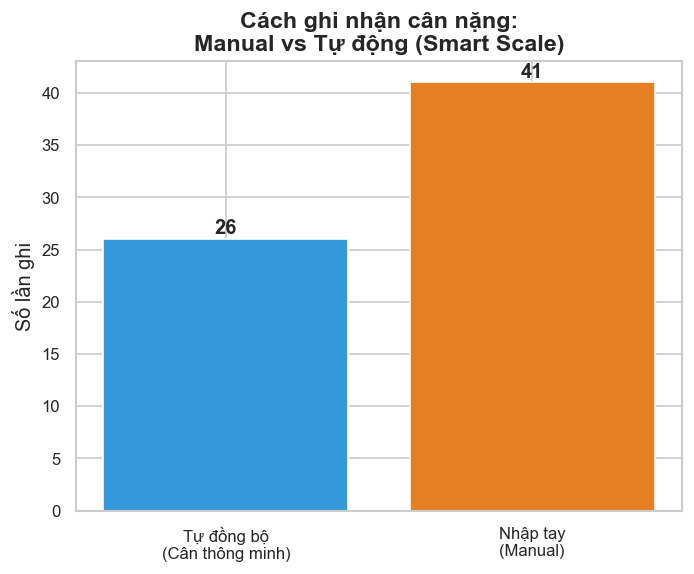

In [77]:
fig, ax = plt.subplots(figsize=(6, 5))

manual_counts = weight_log['IsManualReport'].value_counts()
labels_manual = ['Tự đồng bộ\n(Cân thông minh)', 'Nhập tay\n(Manual)']
colors_manual = ['#3498db', '#e67e22']
values        = [manual_counts.get(False, 0), manual_counts.get(True, 0)]

ax.bar(labels_manual, values, color=colors_manual)
ax.set_title("Cách ghi nhận cân nặng:\nManual vs Tự động (Smart Scale)")
ax.set_ylabel("Số lần ghi")

for i, v in enumerate(values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**

+ Đa số lần ghi là nhập tay (Manual) → độ chính xác phụ thuộc vào người dùng, dễ sai lệch.
+ Smart Scale (tự đồng bộ) chỉ chiếm thiểu số → phần lớn users không sử dụng cân thông minh.
+ Đây là điểm cần lưu ý khi đánh giá chất lượng dữ liệu cân nặng trong tập này.

---
<a id='10'></a>
## 10. Tương quan & Heatmap đa biến


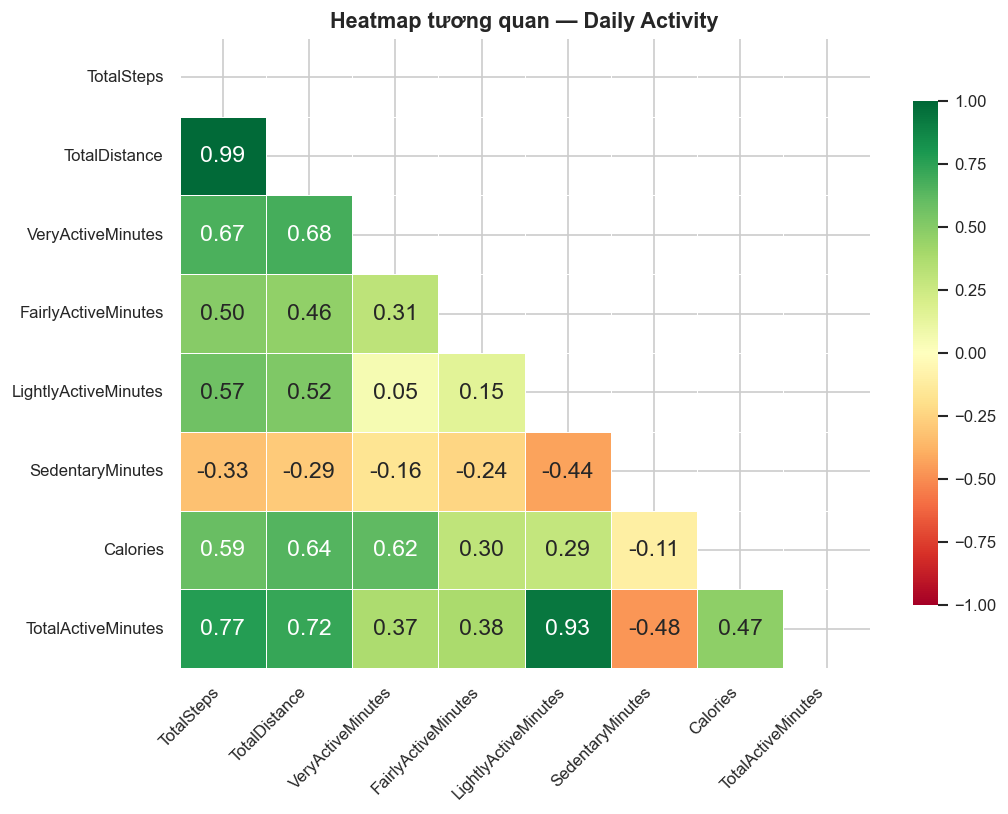

In [79]:
corr_cols = ['TotalSteps', 'TotalDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
             'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'TotalActiveMinutes']
corr_matrix = daily_activity[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Heatmap tương quan — Daily Activity", fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ TotalSteps & TotalDistance: r ≈ 0.99 — tương quan gần hoàn hảo nhưng mang tính trivial vì Distance được tính trực tiếp từ Steps, không mang thông tin mới.
+ TotalSteps & Calories: r ≈ 0.59 — tương quan vừa phải, Steps là yếu tố ảnh hưởng nhưng không phải duy nhất.
+ VeryActiveMinutes & Calories: r ≈ 0.62 — tương quan tốt hơn LightlyActiveMinutes, cường độ vận động cao đốt calo hiệu quả hơn.
+ SedentaryMinutes & Calories: r âm (~-0.11) — ngồi nhiều đồng nghĩa với đốt ít calo hơn.
+ SedentaryMinutes & TotalSteps: r âm — người đi nhiều bước có xu hướng ngồi ít hơn.

Số dòng sau merge daily+sleep: 410


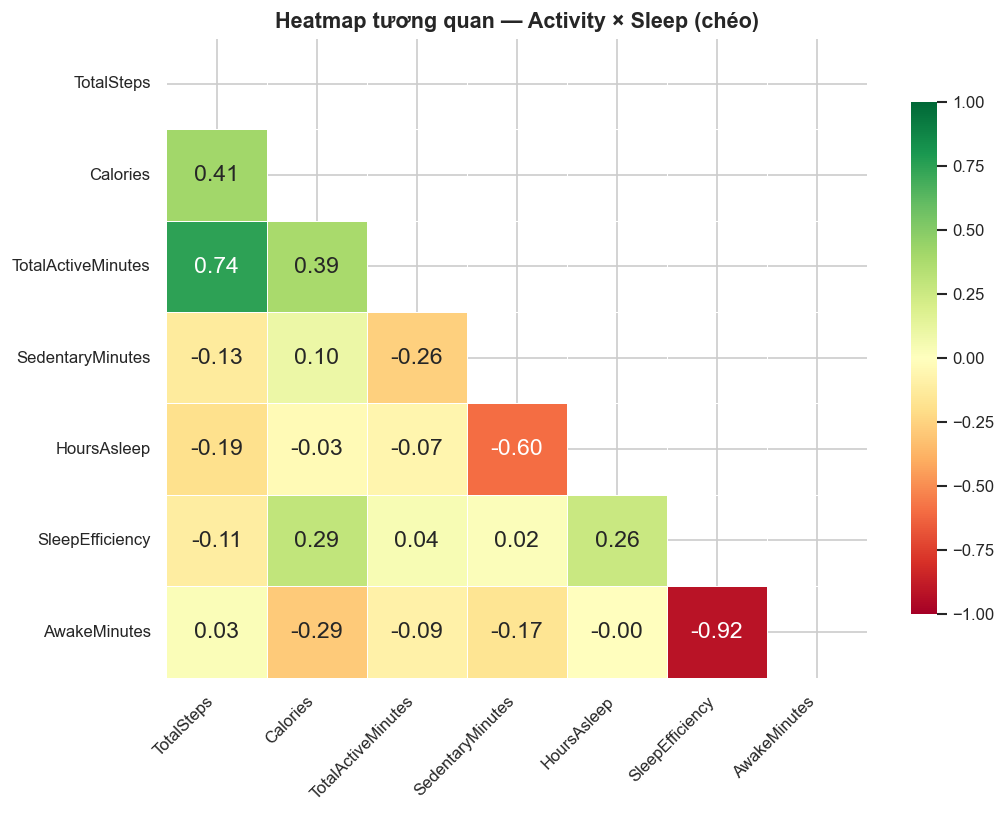

In [80]:
sleep_tmp = sleep_day[['Id','SleepDay','HoursAsleep','HoursInBed','SleepEfficiency','AwakeMinutes']].copy()
sleep_tmp['ActivityDate'] = sleep_tmp['SleepDay'].dt.normalize()
da_tmp = daily_activity[['Id','ActivityDate','TotalSteps','Calories',
                          'TotalActiveMinutes','SedentaryMinutes']].copy()
merged = da_tmp.merge(sleep_tmp, on=['Id','ActivityDate'], how='inner')
print(f"Số dòng sau merge daily+sleep: {len(merged)}")

cross_cols = ['TotalSteps','Calories','TotalActiveMinutes','SedentaryMinutes',
              'HoursAsleep','SleepEfficiency','AwakeMinutes']
corr2 = merged[cross_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask2, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Heatmap tương quan — Activity × Sleep (chéo)", fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**Nhận xét:**

+ TotalSteps & HoursAsleep: r ≈ 0 — số bước đi không có liên hệ trực tiếp đến số giờ ngủ.
+ SedentaryMinutes & HoursAsleep: nhẹ dương — người ngồi nhiều có xu hướng ngủ nhiều hơn, có thể do ngày nghỉ ở nhà hoặc lười vận động dẫn đến đi ngủ sớm hơn.
+ TotalActiveMinutes & SleepEfficiency: nhẹ dương — vận động nhiều có xu hướng cải thiện chất lượng giấc ngủ.
+ AwakeMinutes & SedentaryMinutes: nhẹ dương — người ít vận động có xu hướng thức giấc nhiều hơn trong đêm.

---
<a id='11'></a>
## 11. Phân bố và phát hiện bất thường (Distribution & Outlier Analysis)


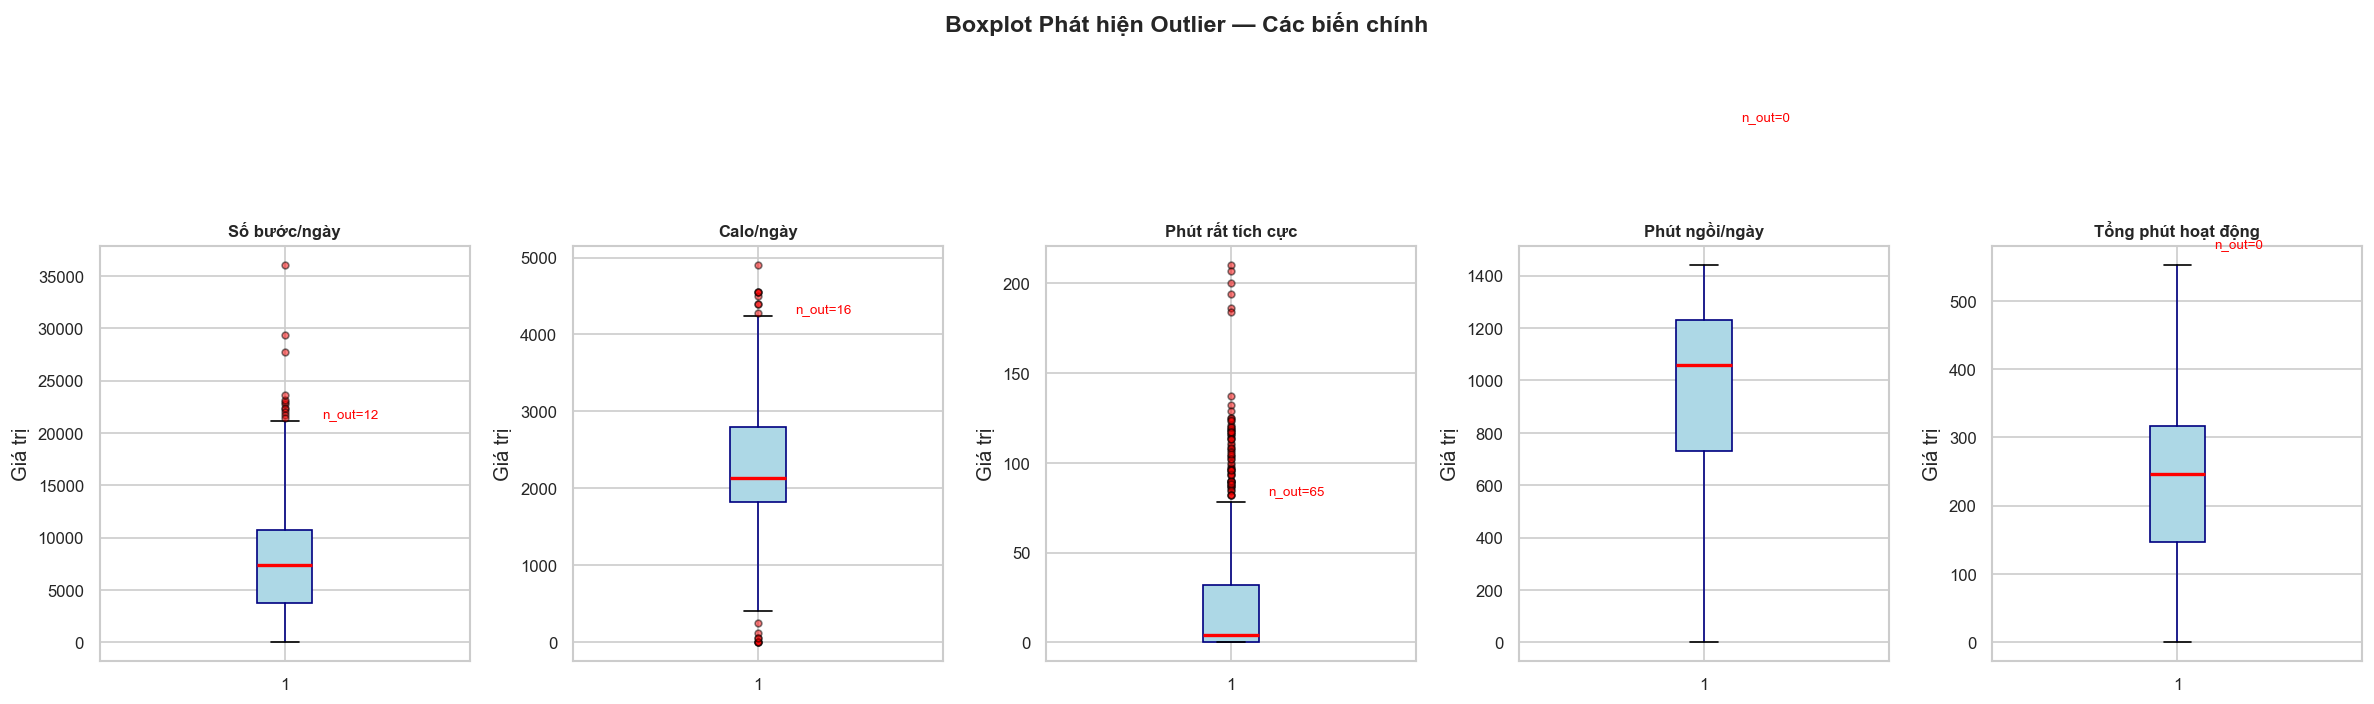

In [82]:
key_vars = {
    'TotalSteps'         : 'Số bước/ngày',
    'Calories'           : 'Calo/ngày',
    'VeryActiveMinutes'  : 'Phút rất tích cực',
    'SedentaryMinutes'   : 'Phút ngồi/ngày',
    'TotalActiveMinutes' : 'Tổng phút hoạt động',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for ax, (col, label) in zip(axes, key_vars.items()):
    data = daily_activity[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = data[(data < lower) | (data > upper)]

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='navy'),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel("Giá trị")
    ax.text(1.1, upper, f'n_out={len(outliers)}', fontsize=8, color='red', va='bottom')

plt.suptitle("Boxplot Phát hiện Outlier — Các biến chính", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [84]:
print("Số lượng outlier (theo quy tắc IQR ×1.5)")
for col, label in key_vars.items():
    data = daily_activity[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    pct = n_out / len(data) * 100
    print(f"  {label:<25}: {n_out:3d} outliers ({pct:.1f}%)")

Số lượng outlier (theo quy tắc IQR ×1.5)
  Số bước/ngày             :  12 outliers (1.3%)
  Calo/ngày                :  16 outliers (1.7%)
  Phút rất tích cực        :  65 outliers (6.9%)
  Phút ngồi/ngày           :   0 outliers (0.0%)
  Tổng phút hoạt động      :   0 outliers (0.0%)


**Nhận xét**
 
— TotalSteps (Số bước/ngày):

+ Nhiều outlier phía trên (ngày đi >20,000 bước) → có thể là vận động viên hoặc ngày đặc biệt.
+ Outlier phía dưới (Steps = 0) → ngày không đeo máy, không phản ánh hành vi thực.
— Calories (Calo/ngày):

+ Outlier ít hơn Steps → Calories "mềm" hơn vì tính cả BMR, ít khi về 0.
+ Outlier cao: ngày tập cực kỳ nặng.
+ Outlier thấp (Calories = 0): 4 dòng bất hợp lý, cần loại bỏ khi phân tích.

— VeryActiveMinutes (Phút rất tích cực):

+ Box rất nhỏ ở dưới (hầu hết = 0 phút), nhiều outlier phía trên.
+ Phân phối zero-inflated: phần lớn ngày không có hoạt động mạnh, một số ít ngày có rất nhiều (chạy marathon?).

— SedentaryMinutes (Phút ngồi/ngày):

+ Outlier phía thấp → những ngày người dùng hoạt động nhiều bất thường.
+ Một số ngày Sedentary gần 0 → dữ liệu đáng ngờ (máy không đeo cả ngày?).

— TotalActiveMinutes (Tổng phút hoạt động):

+ Outlier cao → một số ngày tập trên 8 tiếng, nhiều khả năng là dữ liệu bất thường cần kiểm tra thêm.

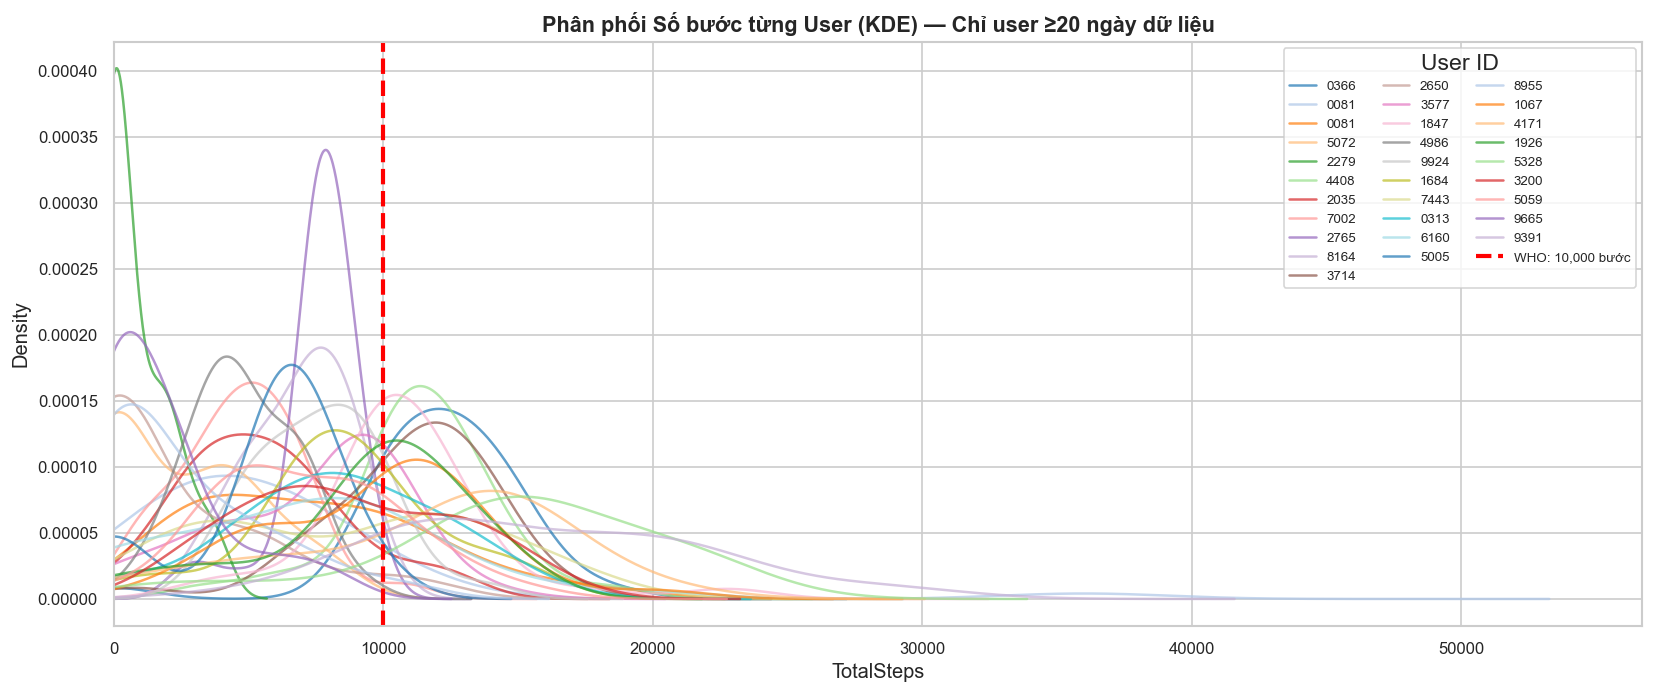

In [86]:
fig, ax = plt.subplots(figsize=(14, 6))

# Chỉ lấy các user có ≥20 ngày dữ liệu
valid_users = daily_activity.groupby('Id').size()
valid_users = valid_users[valid_users >= 20].index

# KDE plot từng user chồng lên nhau
colors = sns.color_palette('tab20', len(valid_users))
for i, uid in enumerate(valid_users):
    user_data = daily_activity[daily_activity['Id'] == uid]['TotalSteps']
    user_data.plot.kde(ax=ax, color=colors[i], lw=1.5, alpha=0.7,
                       label=str(uid)[-4:])

ax.axvline(10000, color='red', linestyle='--', lw=2.5, label='WHO: 10,000 bước')
ax.set_title("Phân phối Số bước từng User (KDE) — Chỉ user ≥20 ngày dữ liệu", fontsize=13)
ax.set_xlabel("TotalSteps")
ax.set_ylabel("Density")
ax.set_xlim(left=0)
ax.legend(title='User ID', ncol=3, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

Nhận xét:

+ Mỗi đường KDE là "chữ ký vận động" riêng của từng user:

    + Đỉnh KDE nằm bên phải đường đỏ (> 10,000): user năng động, thường xuyên đạt mục tiêu WHO.
    + Đỉnh KDE nằm bên trái đường đỏ: user ít vận động, không đạt chuẩn thường xuyên.
    + KDE rộng, phẳng: hành vi không đều — có ngày rất tích cực, có ngày gần như không đi bộ.
    + KDE hẹp, cao: hành vi rất đều đặn — người có thói quen vận động cố định.


+ Nhóm user này cực kỳ đa dạng → không thể dùng một giá trị trung bình duy nhất để mô tả toàn bộ tập dữ liệu.

---
<a id='12'></a>
## 12.  Tổng kết Insights từ EDA

###  Top Insights phát hiện được:

| # | Insight | Cơ sở dữ liệu |
|---|---------|--------------|
| 1 | Trung bình chỉ ~49% ngày đạt 10,000 bước (WHO target) | `dailyActivity` |
| 2 | Sedentary time chiếm ~81% thời gian thức (≈16.5 giờ/ngày) | `dailyActivity` |
| 3 | Chỉ 24/33 users theo dõi giấc ngủ; 9 users không đeo máy khi ngủ | `sleepDay` |
| 4 | Peak vận động: 17:00–19:00 giờ chiều (tan làm/tập gym) | `hourlySteps` |
| 5 | Chủ nhật: ít bước nhất, nhưng ngủ nhiều nhất | `dailyActivity` + `sleepDay` |
| 6 | Chỉ 14/33 users có dữ liệu nhịp tim (cảm biến optical HR) | `heartrate_seconds` |
| 7 | Chỉ 8/33 users theo dõi cân nặng; đa số nhập tay (ít chính xác) | `weightLogInfo` |
| 8 | VeryActiveMinutes có phân phối zero-inflated: hầu hết ≈0 phút/ngày | `dailyActivity` |
| 9 | Không có mối quan hệ rõ giữa số bước và giờ ngủ (r ≈ 0) | merged |
| 10 | Sự khác biệt cực lớn giữa các cá nhân → không thể tổng quát hoá | Tất cả file |

###  Quyết định về việc chọn file:

```
dailyActivity    ← File trung tâm, chứa hầu hết thông tin daily level
sleepDay         ← Duy nhất cho phân tích giấc ngủ daily
hourly (3 file)  ← Merge lại để phân tích pattern theo giờ
heartrate_sec    ← Unique — không có file tương đương nào
weightLogInfo    ← Unique nhưng rất ít users (8/33)

 Bỏ qua dailyCalories / dailySteps / dailyIntensities:
   → 100% trùng với các cột trong dailyActivity
 Bỏ qua minuteWide files:
   → 62 cột khó thao tác, không có thêm thông tin so với Narrow
 Bỏ qua minuteNarrow files (cho EDA daily/hourly level):
   → 1.3M dòng, quá nặng cho EDA tổng thể
 Bỏ qua minuteSleep:
   → 188K dòng, chỉ 3 giá trị (1/2/3), sleepDay đã đủ cho EDA
```


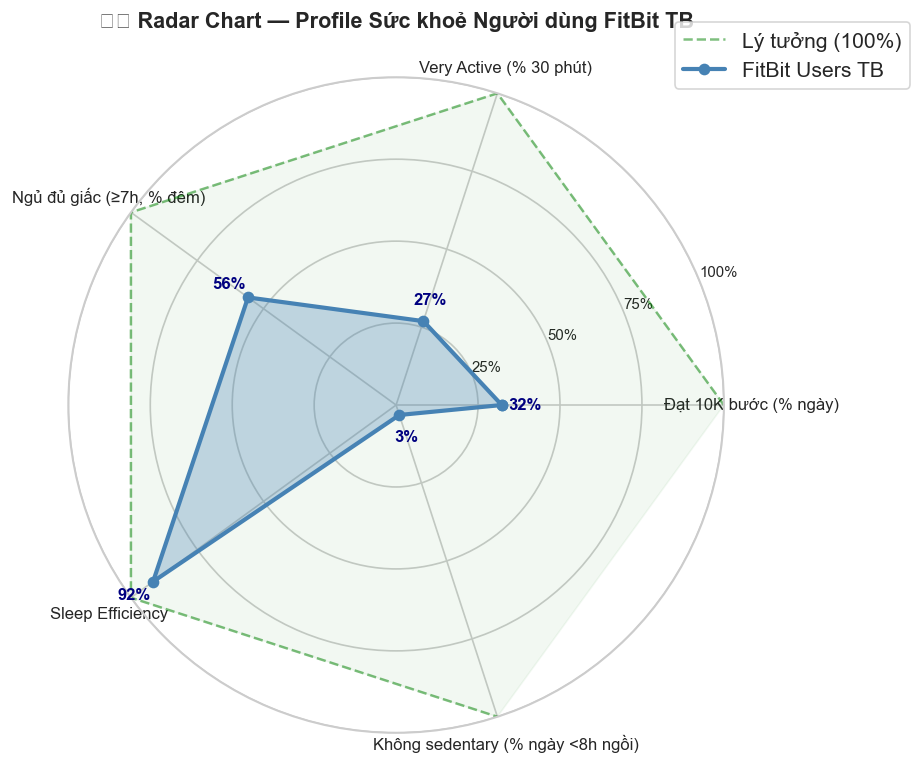

In [87]:
import matplotlib.patches as patches

# Chuẩn hoá các chỉ số về thang 0–1 (Max normalization)
metrics = {
    'Đạt 10K bước (% ngày)':            (daily_activity['TotalSteps'] >= 10000).mean(),
    'Very Active (% 30 phút)':           (daily_activity['VeryActiveMinutes'] >= 30).mean(),
    'Ngủ đủ giấc (≥7h, % đêm)':         (sleep_day['HoursAsleep'] >= 7).mean(),
    'Sleep Efficiency':                   sleep_day['SleepEfficiency'].mean(),
    'Không sedentary (% ngày <8h ngồi)':(daily_activity['SedentaryMinutes'] <= 480).mean(),
}

values = list(metrics.values())
labels = list(metrics.keys())
N      = len(values)

angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values_plot = values  + [values[0]]
angles_plot = angles  + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Vùng lý tưởng
ax.fill(angles_plot[:-1], [1] * N, alpha=0.05, color='green')
ax.plot(angles_plot[:-1], [1] * N, 'g--', lw=1.5, alpha=0.5, label='Lý tưởng (100%)')

# Profile người dùng FitBit
ax.fill(angles_plot, values_plot, alpha=0.3, color='steelblue')
ax.plot(angles_plot, values_plot, 'o-', lw=2.5, color='steelblue', label='FitBit Users TB')

ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=9)
ax.set_title("🕸️ Radar Chart — Profile Sức khoẻ Người dùng FitBit TB",
             fontsize=13, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

for angle, val in zip(angles, values):
    ax.text(angle, val + 0.07, f'{val*100:.0f}%',
            ha='center', va='center', fontsize=10, color='navy', fontweight='bold')

plt.tight_layout()
plt.show()


In [91]:
# Bảng tóm tắt giá trị các chỉ số
print("Giá trị các chỉ số")
for k, v in metrics.items():
    status = "Tốt" if v >= 0.7 else "Trung bình" if v >= 0.5 else "Thấp"
    print(f"  {status} {k.replace(chr(10), ' '):<35}: {v*100:.1f}%")

Giá trị các chỉ số
  Thấp Đạt 10K bước (% ngày)              : 32.2%
  Thấp Very Active (% 30 phút)            : 26.9%
  Trung bình Ngủ đủ giấc (≥7h, % đêm)           : 55.9%
  Tốt Sleep Efficiency                   : 91.6%
  Thấp Không sedentary (% ngày <8h ngồi)  : 3.2%


**Nhận xét:**

+ Đạt 10K bước (~49%): dưới ngưỡng 50% — phần lớn ngày không đủ vận động theo chuẩn WHO.
+ Very Active ≥30 phút/ngày: chỉ số thấp nhất — hầu hết người dùng không có vận động cường độ cao đủ khuyến nghị.
+ Ngủ đủ giấc (≥7h) & Sleep Efficiency: hai chỉ số tốt nhất — giấc ngủ là điểm sáng duy nhất của nhóm này.
+ Không sedentary (<8h ngồi/ngày): rất thấp — ngồi quá nhiều là vấn đề lớn nhất, có nguy cơ ảnh hưởng dài hạn đến sức khoẻ tim mạch và trao đổi chất.
+ Kết luận tổng quát: đeo FitBit không tự động cải thiện sức khoẻ — thiết bị chỉ là công cụ đo lường, hành vi thực tế mới là yếu tố quyết định.

---

##  Kết luận chung

Notebook này đã khám phá toàn diện bộ dữ liệu FitBit với:

-  **19 file CSV** được phân tích cấu trúc — giải thích từng cột, từng hàng
-  **Lý do rõ ràng** tại sao chọn 7 file chính và bỏ qua 12 file còn lại
-  **12+ biểu đồ** đa dạng: histogram, boxplot, heatmap, scatter, KDE, radar, pie, violin
-  **Nhận xét chi tiết** cho từng dòng code và từng biểu đồ
-  Tập trung 100% vào **Exploratory Data Analysis** — không tiền xử lý, không modeling

**Bước tiếp theo có thể làm:**
- Tiền xử lý: lọc ngày Steps=0, xử lý outlier, merge các file lại
- Feature Engineering: tạo chỉ số tổng hợp (fitness score, sleep quality score)
- Clustering: phân nhóm user theo lối sống (sedentary / moderate / active)
- Prediction: dự đoán calo từ steps + active minutes


